## 0. Project setup and scalar potential

In this section we fix the **project path** and the **model parameters** used throughout the notebook.

We work with a double–well scalar potential $V(\phi)$ with a **false vacuum** at $\phi = v_1$ and a **true vacuum** at $\phi = v_2$.

At finite chemical potential $\omega$ the relevant thermodynamic potential is the **grand potential**
$$
\Omega(\phi) = V(\phi) - \omega^2 \phi^2 \,,
$$
which controls the metastability of the false vacuum and the nucleation of the critical bubble (consistent with the 2D PDE: $W(\rho_0^2)=\omega^2 \Leftrightarrow V'(\rho_0)=2\omega^2\rho_0$).


In [1]:
# ============================================================================
# Project path and configuration
# ============================================================================

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Model parameters (same potential as in the 4D bounce notebook)
PHI0 = 1.999   # field value near the center of the bounce
V1 = 1.0       # false vacuum
V2 = 2.0       # true vacuum
OMEGA = 0.6    # chemical potential ω (can be changed)

print(f"Project root: {PROJECT_ROOT}")
print(f"Potential: false vacuum at φ={V1}, true vacuum at φ={V2}")
print(f"φ0 = {PHI0},  ω = {OMEGA}")

Project root: /home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/BubbleX
Potential: false vacuum at φ=1.0, true vacuum at φ=2.0
φ0 = 1.999,  ω = 0.6


In [2]:
# ============================================================================
# Imports
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from Q_ball_finder.grid import build_grid, RadialTimeGrid

from Bubble_finder.potential_bubble import (
    V_phi, dV_dphi, d2V_dphi2, Omega_phi, dOmega_dphi, d2Omega_dphi2, vacua_of_Omega,
)
from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver, make_potential_from_V, solve_rho0_for_omega
from Bubble_finder.bounce_1d import solve_bounce
from Bubble_finder.ansatz_bubble import (
    AnsatzParams, build_seed_bubble, compute_negative_mode_1d, compute_Dp_shooting_1d, bc_projector_y,
    make_q_ball_objects, make_bubble_profile_1d_from_solve_bounce, PotentialModel,
)
from Bubble_finder.ansatz_bubble import select_best_seed

# Potential U(ρ)=V(φ) for the 2D solver (requires PHI0, V1, V2 from previous cell)
U, dU, d2U = make_potential_from_V(V_phi, dV_dphi, d2V_dphi2, phi0=PHI0, v1=V1, v2=V2)

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}",
})
plt.rcParams["figure.figsize"] = (7, 4.8)

print("Imports completed.")

Imports completed.


## 1. One-dimensional critical bubble

In this section we compute the **O(3)-symmetric one-dimensional critical bubble** $\phi_{\mathrm{cb}}(r)$ at fixed chemical potential $\omega$.

The radial equation for the bounce profile in $d$ spatial dimensions is
$$
\phi''(r) + \frac{d-1}{r}\,\phi'(r) = \frac{\partial \Omega(\phi)}{\partial \phi} \, ,
$$
with $d = 3$ and grand potential $\Omega(\phi) = V(\phi) - \omega^2 \phi^2$, so that $\partial\Omega/\partial\phi = V'(\phi) - 2\omega^2\phi$.

We impose:
- regularity at the origin, $\phi'(0) = 0$, so that the solution is smooth at $r = 0$;
- approach to the false vacuum as $r \to \infty$, $\phi(r) \to \phi_\text{false}$.

We use a simple **overshoot/undershoot** algorithm with bisection in the initial value $\phi(0)$ to find the bounce profile
$$
\{ r_{\mathrm{cb}},\, \phi_{\mathrm{cb}}(r) \} \, ,
$$
which will later be used as input for the 2D construction.


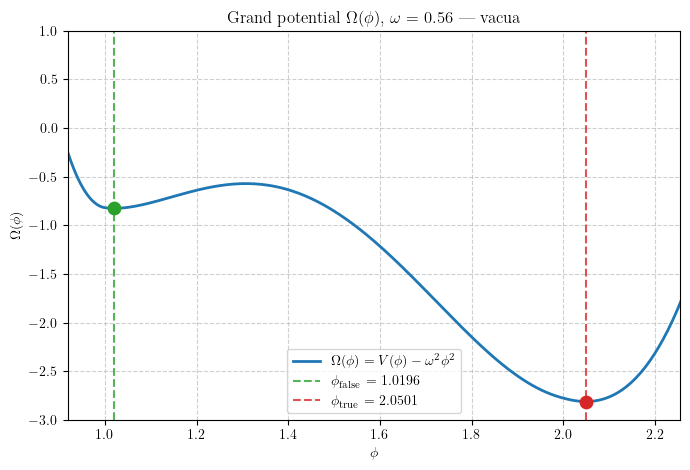

Solving O(3) bounce solution...
Parameters: φ₀=1.999, v1=1.0, v2=2.0, ω=0.564281
Analytical action (d=4, Q=0): S₀ = 80.590466
[vacua_of_Omega] ω=0.564281
  phi_false=1.01975463135  Ω_false=-0.824164956232  dΩ=-1.15e-07  (ω²-W)=5.62e-08  Ω''=2.606e+01
  phi_true =2.04979661929  Ω_true =-2.80909095343  dΩ=8.08e-10  (ω²-W)=-1.97e-10  Ω''=3.283e+01
Vacua of Ω: phi_false=1.0197546314, phi_true=2.0497966193
  Iteration 0: Undershoot, φ(0)=1.534776, φ(∞)=1.255485, r_stop=1.1802
  Iteration 10: Undershoot, φ(0)=1.965804, φ(∞)=1.021035, r_stop=2.2452
  Iteration 20: Undershoot, φ(0)=1.965831, φ(∞)=1.019870, r_stop=2.6787
  Converged after 27 iterations: φ(0)=1.965831, φ(∞)=1.019763, φ'(∞)=8.894e-21

Bounce solution found:
  φ(0) = 1.965831
  φ(∞) ≈ 1.019763 (target false = 1.019755)
  r_max = 3.15
  Number of points: 1000
  phi range: [1.019763, 1.965831]


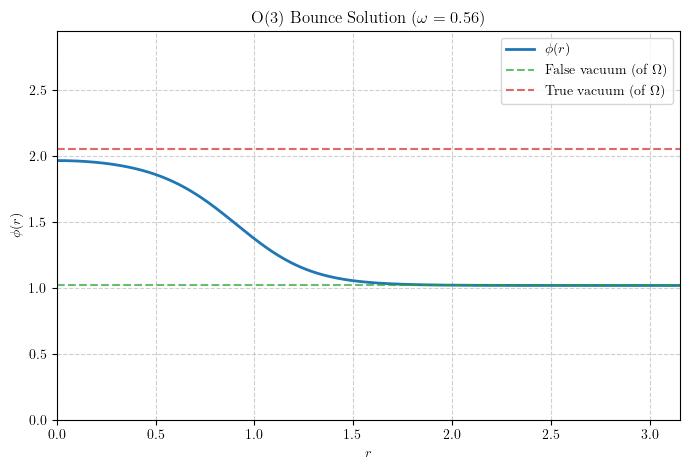

In [3]:
# ============================================================================
# 1D Bounce: parameters, vacua (grid), plot Ω(φ), solve (solve_bounce from bounce_1d)
# ============================================================================

# Parameters
PHI0_BOUNCE = PHI0
V1_BOUNCE = V1
V2_BOUNCE = V2
OMEGA_BOUNCE = 0.564281#OMEGA
D = 3
R0 = 1e-11
RMAX = 10.0
MAX_ITER = 100
VERBOSE = True

# Find vacua of Ω(φ) = V(φ) - ω²φ² using efficient grid method (two grids, then assign false/true by Ω)
phi_grid1 = np.linspace(max(0.5, V1_BOUNCE - 0.2), min(V2_BOUNCE - 0.1, V1_BOUNCE + 0.2), 500)
phi_grid2 = np.linspace(max(V1_BOUNCE + 0.1, V2_BOUNCE - 0.2), V2_BOUNCE+0.2, 500)
Omega_grid1 = np.array([Omega_phi(phi, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE) for phi in phi_grid1])
Omega_grid2 = np.array([Omega_phi(phi, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE) for phi in phi_grid2])
idx_min1 = np.argmin(Omega_grid1)
idx_min2 = np.argmin(Omega_grid2)
phi_near_v1 = phi_grid1[idx_min1]
phi_near_v2 = phi_grid2[idx_min2]
Omega_near_v1 = Omega_phi(phi_near_v1, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE)
Omega_near_v2 = Omega_phi(phi_near_v2, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE)
if Omega_near_v1 > Omega_near_v2:
    phi_false_grid, phi_true_grid = phi_near_v1, phi_near_v2
    Omega_false_grid, Omega_true_grid = Omega_near_v1, Omega_near_v2
else:
    phi_false_grid, phi_true_grid = phi_near_v2, phi_near_v1
    Omega_false_grid, Omega_true_grid = Omega_near_v2, Omega_near_v1

# Plot Ω(φ) and mark the two minima to verify they correspond to the vacua
# Free range: no clipping; extend below v1 and especially above v2
phi_plot = np.linspace(0.5, 3.0, 500)
Omega_plot = np.array([Omega_phi(phi, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE) for phi in phi_plot])
fig, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(phi_plot, Omega_plot, lw=2, color="C0", label=r"$\Omega(\phi) = V(\phi) - \omega^2\phi^2$")
ax.axvline(phi_false_grid, color="C2", ls="--", lw=1.5, label=rf"$\phi_{{\mathrm{{false}}}}$ = {phi_false_grid:.4f}", alpha=0.8)
ax.axvline(phi_true_grid, color="C3", ls="--", lw=1.5, label=rf"$\phi_{{\mathrm{{true}}}}$ = {phi_true_grid:.4f}", alpha=0.8)
ax.scatter([phi_false_grid], [Omega_false_grid], color="C2", s=80, zorder=5)
ax.scatter([phi_true_grid], [Omega_true_grid], color="C3", s=80, zorder=5)
ax.set_xlabel(r"$\phi$")
ax.set_ylabel(r"$\Omega(\phi)$")
ax.set_xlim(phi_false_grid*0.9, phi_true_grid*1.1)
ax.set_ylim(-3, 1.0)
ax.set_title(rf"Grand potential $\Omega(\phi)$, $\omega$ = {OMEGA_BOUNCE:.2f} — vacua")
ax.legend()
ax.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Analytical Euclidean action for d=4, Q=0 (used for display only)
from scipy.special import spence
def S0_analytical(phi0):
    """S₀ = -π²/3 [φ₀ - 1 + Li₂((φ₀-1)/(φ₀-2))]; Li₂(z) = spence(1-z)."""
    term = (phi0 - 1) / (phi0 - 2)
    Li2_val = spence(1 - term)
    return -np.pi**2 / 3.0 * (phi0 - 1 + Li2_val)

# Solve bounce with chosen parameters
print("Solving O(3) bounce solution...")
print(f"Parameters: φ₀={PHI0_BOUNCE}, v1={V1_BOUNCE}, v2={V2_BOUNCE}, ω={OMEGA_BOUNCE}")
print(f"Analytical action (d=4, Q=0): S₀ = {S0_analytical(PHI0_BOUNCE):.6f}")
r_bounce, phi_bounce, phi0_bounce, phi_false_bounce, phi_true_bounce = solve_bounce(
    PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE, 
    d=D, r0=R0, rmax=RMAX, max_iter=MAX_ITER, verbose=VERBOSE
)

if r_bounce is not None:
    print(f"\nBounce solution found:")
    print(f"  φ(0) = {phi0_bounce:.6f}")
    print(f"  φ(∞) ≈ {phi_bounce[-1]:.6f} (target false = {phi_false_bounce:.6f})")
    print(f"  r_max = {r_bounce[-1]:.2f}")
    print(f"  Number of points: {len(r_bounce)}")
    print(f"  phi range: [{phi_bounce.min():.6f}, {phi_bounce.max():.6f}]")
    
    # Update phi_false and phi_true with analytical values
    phi_false = phi_false_grid
    phi_true = phi_true_grid
    
    # Plot bounce solution
    fig, ax = plt.subplots(figsize=(7, 4.8))
    ax.plot(r_bounce, phi_bounce, lw=2, color='C0', label=r"$\phi(r)$")
    ax.axhline(phi_false, color='C2', ls='--', lw=1.5, label=rf"False vacuum (of $\Omega$)", alpha=0.7)
    ax.axhline(phi_true, color='C3', ls='--', lw=1.5, label=rf"True vacuum (of $\Omega$)", alpha=0.7)
    ax.set_xlabel(r"$r$")
    ax.set_ylabel(r"$\phi(r)$")
    ax.set_xlim(0, r_bounce[-1])
    ax.set_ylim(0, phi_bounce.max()*1.5)
    ax.set_title(rf"O(3) Bounce Solution ($\omega = {OMEGA_BOUNCE:.2f}$)")
    ax.legend()
    ax.grid(True, ls="--", alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("Failed to find bounce solution.")

## 1b. Homogeneous configuration and charge-matched bubble

We fix the **reference volume** to a ball of radius $r_{\mathrm{max}} = 10$ and:

1. **Homogeneous configuration** at the same chemical potential $\omega$ (from the notebook): $\phi = \phi_{\mathrm{false}}(\omega)$ constant. Its charge on the ball $[0, r_{\mathrm{max}}]$ is
   $$Q_{\mathrm{hom}} = 4\pi\,\omega\,\phi_{\mathrm{false}}^2\,\frac{r_{\mathrm{max}}^3}{3}\;.$$

2. **Bubble with the same charge**: we search for $\tilde{\omega}$ (generally $\tilde{\omega} < \omega$) such that the critical bubble at $\tilde{\omega}$, when integrated on the **same** volume $[0, r_{\mathrm{max}}]$, has total charge $Q = Q_{\mathrm{hom}}$. Since the bubble profile $\phi(r)$ is defined only up to some $r_{\mathrm{max}}^{\mathrm{bubble}}$ (often $< r_{\mathrm{max}}$), we apply a **volume correction**: we integrate the bubble from $0$ to $r_{\mathrm{max}}^{\mathrm{bubble}}$ and extend from $r_{\mathrm{max}}^{\mathrm{bubble}}$ to $r_{\mathrm{max}}$ with $\phi = \phi_{\mathrm{false}}(\tilde{\omega})$, so that the integral is over the same ball $[0, r_{\mathrm{max}}]$.

In [4]:
# ============================================================================
# Homogeneous charge at r_max = 10 and charge-matched bubble (volume-corrected)
# ============================================================================

from scipy.optimize import root_scalar
from Bubble_finder.observables_2d import Q_homogeneous_ball, compute_charge_1d_volume_corrected

R_MAX_REF = r_bounce[-1]#10.0   # reference volume: ball of radius r_max = 10

# 1) Homogeneous configuration at omega = OMEGA (same as bounce)
phi_false_omega = phi_false_bounce   # from section 1 (vacuum of Omega at OMEGA)
Q_hom = Q_homogeneous_ball(OMEGA, phi_false_omega, R_MAX_REF)
print(f"Reference volume: r_max = {R_MAX_REF}")
print(f"Homogeneous config (omega = {OMEGA}): phi_false = {phi_false_omega:.6f}, Q_hom = {Q_hom:.6f}")

def Q_bubble_at_omega_tilde(omega_tilde):
    """Charge of the critical bubble at omega_tilde, integrated on [0, R_MAX_REF] with volume correction."""
    r_b, phi_b, _, phi_false_t, _ = solve_bounce(
        PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, omega_tilde,
        d=D, r0=R0, rmax=max(RMAX, R_MAX_REF), max_iter=MAX_ITER, verbose=False
    )
    if r_b is None:
        return np.nan
    return compute_charge_1d_volume_corrected(r_b, phi_b, omega_tilde, R_MAX_REF, phi_false_t)

# 2) Find omega_tilde such that Q_bubble(omega_tilde) = Q_hom (omega_tilde typically < OMEGA)
omega_lo = 0.01   # lower bound: bounce must exist
omega_hi = OMEGA
try:
    res_Q = root_scalar(lambda w: Q_bubble_at_omega_tilde(w) - Q_hom, bracket=[omega_lo, omega_hi], method='brentq')
    omega_tilde = res_Q.root
except ValueError:
    # If bracket fails (e.g. Q(omega_lo) > Q_hom), try narrower bracket
    omega_lo = 0.5
    res_Q = root_scalar(lambda w: Q_bubble_at_omega_tilde(w) - Q_hom, bracket=[omega_lo, omega_hi], method='brentq')
    omega_tilde = res_Q.root

# Recompute bubble at omega_tilde for later use
r_bubble_Q, phi_bubble_Q, phi0_bubble_Q, phi_false_tilde, phi_true_tilde = solve_bounce(
    PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, omega_tilde,
    d=D, r0=R0, rmax=max(RMAX, R_MAX_REF), max_iter=MAX_ITER, verbose=False
)
Q_bubble_corrected = compute_charge_1d_volume_corrected(r_bubble_Q, phi_bubble_Q, omega_tilde, R_MAX_REF, phi_false_tilde)

print(f"\nCharge-matched bubble:")
print(f"  omega_tilde = {omega_tilde:.6f}  ( < omega = {OMEGA} )")
print(f"  Q_bubble (volume-corrected to r_max={R_MAX_REF}) = {Q_bubble_corrected:.6f}")
print(f"  Q_hom = {Q_hom:.6f}  (match: |Q_bubble - Q_hom| = {abs(Q_bubble_corrected - Q_hom):.2e})")
print(f"  Bubble r_max = {r_bubble_Q[-1]:.4f}")
rho_hom = float(phi_false_omega)
phi_bubble_at_rmax = float(np.interp(R_MAX_REF, r_bubble_Q, phi_bubble_Q))
print(f"  rho_hom = {rho_hom:.6f}")
print(f"  1D bubble at r = r_max (= {R_MAX_REF}): phi = {phi_bubble_at_rmax:.6f}")

OMEGA = OMEGA
OMEGA_TILDE = omega_tilde

Reference volume: r_max = 3.1538399282779626
Homogeneous config (omega = 0.6): phi_false = 1.019755, Q_hom = 81.987978

Charge-matched bubble:
  omega_tilde = 0.557135  ( < omega = 0.6 )
  Q_bubble (volume-corrected to r_max=3.1538399282779626) = 81.987978
  Q_hom = 81.987978  (match: |Q_bubble - Q_hom| = 5.54e-11)
  Bubble r_max = 3.1030
  rho_hom = 1.019755
  1D bubble at r = r_max (= 3.1538399282779626): phi = 1.019142


## 2. Energy and charge of the 1D bubble

From the 1D profile $\phi_{\mathrm{cb}}(r)$ we extract the **energy** and **charge** of the configuration.

In the grand–canonical ensemble the energy functional is schematically
$$
E[\phi] = 4\pi \int_0^{\infty} \mathrm{d}r\, r^2\left[\tfrac12 (\partial_r \phi)^2 + \Omega(\phi) - \Omega(\phi_\text{false})\right] ,
$$
where $\Omega(\phi)$ is the grand potential and $\phi_\text{false}$ denotes the metastable minimum.
The conserved charge associated with the chemical potential $\omega$ is
$$
Q[\phi] \propto 4\pi \int_0^{\infty} \mathrm{d}r\, r^2\, \phi^2(r) \, .
$$

In the implementation below we use the same potential functions as in the 2D solver and perform simple radial integrals (Simpson rule) to obtain representative values of $E$ and $Q$ for the 1D bounce, together with the corresponding **energy** and **charge densities**.


In [5]:
# ============================================================================
# Compute Energy and Charge (1D bounce — from observables_2d)
# ============================================================================

from Bubble_finder.observables_2d import (
    compute_energy,
    compute_charge,
    compute_energy_density,
    compute_charge_density,
)

if r_bounce is not None:
    # Use the bounce parameters
    E_bounce = compute_energy(r_bounce, phi_bounce, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE, phi_false_bounce)
    Q_bounce = compute_charge(r_bounce, phi_bounce, OMEGA_BOUNCE)
    rho_E_bounce = compute_energy_density(r_bounce, phi_bounce, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE, phi_false_bounce)
    rho_Q_bounce = compute_charge_density(r_bounce, phi_bounce, OMEGA_BOUNCE)
    
    print(f"Bounce solution observables:")
    print(f"  Energy: E = {E_bounce:.6f}")
    print(f"  Charge: Q = {Q_bounce:.6f}")
    print(f"  E/Q = {E_bounce/Q_bounce:.6f}")
    print(f"  Energy density: ρ_E = {rho_E_bounce:.6f}")
    print(f"  Charge density: ρ_Q = {rho_Q_bounce:.6f}")

Bounce solution observables:
  Energy: E = 2.803657
  Charge: Q = 82.938236
  E/Q = 0.033804
  Energy density: ρ_E = 0.021336
  Charge density: ρ_Q = 0.631171


## 3. Negative mode around the 1D bubble

We now compute the **negative mode** $\xi(r)$ describing small fluctuations around the 1D critical bubble.

The fluctuation operator has the schematic form
$$
\mathcal{O} = -\frac{\mathrm{d}^2}{\mathrm{d} r^2} + V''\bigl(\phi_{\mathrm{cb}}(r)\bigr) \, ,
$$
and we impose Dirichlet boundary conditions on $u(r) = r\,\xi(r)$,
$$
u(r) = r\,\xi(r) \quad \Rightarrow \quad u(0) = 0 , \quad u(r_{\max}) = 0 \, ,
$$
so that the mode is regular at the origin and vanishes at the numerical boundary.

Using the helper function `compute_negative_mode` from `Bubble_finder.ansatz_bubble`, we obtain the lowest (negative) eigenvalue and its eigenfunction $\xi(r)$, which will be used to build the 2D ansätze in Euclidean $(r,\tau)$ space.


Negative mode (2-component) computed:
  Radial range: r in [0.0000, 3.1538] (R_MIN_NEG=0.0, R_MAX_NEG=None)
  xi_y[0], xi_ybar[0] = 0.000000e+00, 0.000000e+00  (both ~0 for regularity)
  (For real field phi=phibar we have y1d=ybar1d so xi_y and xi_ybar can coincide.)
  lambda = -9.563834e+00
  gamma = sqrt(-lambda) = 3.092545e+00
  beta_natural = 2*pi/gamma = 2.031720e+00


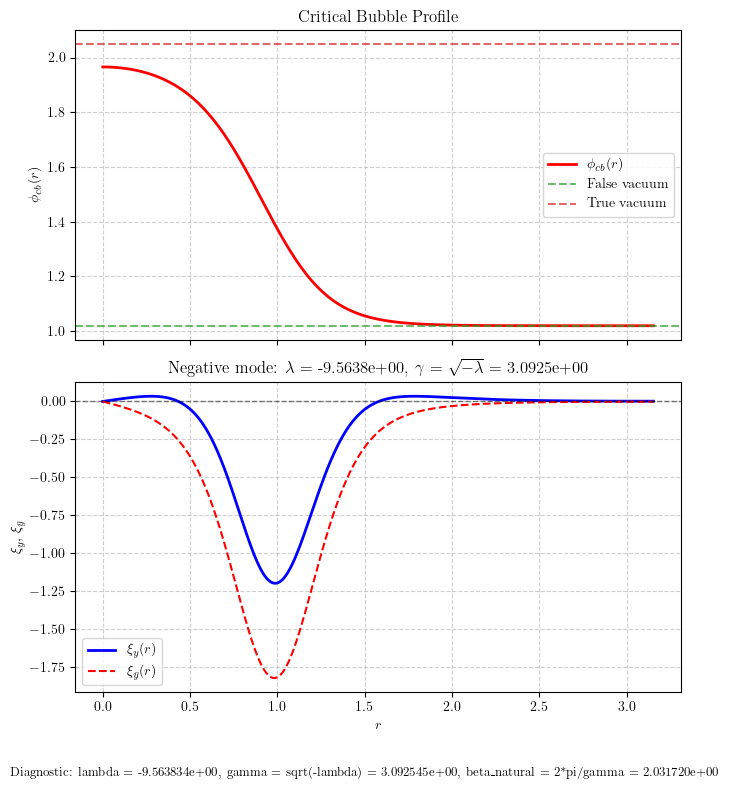

In [6]:
# ============================================================================
# Compute Negative Mode Around Critical Bubble (centralized in ansatz_bubble)
# ============================================================================

from Bubble_finder.ansatz_bubble import (
    compute_negative_mode_from_bounce,
    compute_Dp_shooting_1d,
    prepare_negative_mode_region,
)

# Radial range for negative-mode calculation (None = use full 1D profile)
R_MIN_NEG = 0.0
R_MAX_NEG = None

unstable_mode = None
beta_natural = 40.0

if r_bounce is not None and phi_bounce is not None:
    try:
        unstable_mode = compute_negative_mode_from_bounce(
            r_bounce, phi_bounce, phi_false_bounce, U, dU, d2U, OMEGA_TILDE,
            r_min=R_MIN_NEG, r_max=R_MAX_NEG,
            gamma_scan_neg=(0.01, 5.0), n_scan_neg=80,
            gamma_scan_dp=(0.01, 10.0), n_scan_dp=80,
            sign_convention=1,
        )
        beta_natural = unstable_mode.beta_natural
    except RuntimeError as e:
        if "Could not bracket" in str(e):
            r, phi_slice, potential_1d, dr, phi_false = prepare_negative_mode_region(
                r_bounce, phi_bounce, phi_false_bounce, U, dU, d2U,
                r_min=R_MIN_NEG, r_max=R_MAX_NEG,
            )
            result_dp_diag = compute_Dp_shooting_1d(
                r=r, phi=phi_slice, phibar=phi_slice, potential=potential_1d, omega=OMEGA,
                gamma_scan=(0.01, 5), n_scan=80, require_bracket=False,
            )
            gg = result_dp_diag["gamma_grid"]
            Dp = result_dp_diag["Dp_vals"]
            fig_d, ax_d = plt.subplots(1, 1, figsize=(8, 4))
            ax_d.plot(gg, Dp, 'o-', lw=1, ms=3, label=r'$D_p(\gamma)$')
            ax_d.axhline(0, color='k', ls='--', lw=1)
            ax_d.set_xlabel(r'$\gamma$')
            ax_d.set_ylabel(r'$D_p(\gamma)$')
            ax_d.set_title('Diagnostic: D_p(γ) shooting (no sign change found in range)')
            ax_d.grid(True, alpha=0.5)
            plt.tight_layout()
            plt.show()
            print("D_p scan: γ in [%.4f, %.4f]; min(Dp)=%.4e, max(Dp)=%.4e" % (gg[0], gg[-1], np.min(Dp), np.max(Dp)))
        raise

    # Print and plot
    r = unstable_mode.r
    xi_y, xi_ybar = unstable_mode.xi_y, unstable_mode.xi_ybar
    lam_neg, gamma = unstable_mode.lam_neg, unstable_mode.gamma
    print("Negative mode (2-component) computed:")
    print(f"  Radial range: r in [{r[0]:.4f}, {r[-1]:.4f}] (R_MIN_NEG={R_MIN_NEG}, R_MAX_NEG={R_MAX_NEG})")
    print(f"  xi_y[0], xi_ybar[0] = {xi_y[0]:.6e}, {xi_ybar[0]:.6e}  (both ~0 for regularity)")
    print(f"  (For real field phi=phibar we have y1d=ybar1d so xi_y and xi_ybar can coincide.)")
    print(f"  lambda = {lam_neg:.6e}")
    print(f"  gamma = sqrt(-lambda) = {gamma:.6e}")
    print(f"  beta_natural = 2*pi/gamma = {beta_natural:.6e}")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), sharex=True)
    ax1.plot(r_bounce, phi_bounce, 'r-', lw=2, label=r"$\phi_{cb}(r)$")
    ax1.axhline(phi_false_bounce, color='C2', ls='--', lw=1.5, label="False vacuum", alpha=0.7)
    ax1.axhline(phi_true_bounce if 'phi_true_bounce' in globals() else phi_bounce[0],
                color='C3', ls='--', lw=1.5, label="True vacuum", alpha=0.7)
    ax1.set_ylabel(r"$\phi_{cb}(r)$")
    ax1.set_title("Critical Bubble Profile")
    ax1.legend()
    ax1.grid(True, ls="--", alpha=0.6)
    ax2.plot(r, xi_y, 'b-', lw=2, label=r"$\xi_y(r)$")
    ax2.plot(r, xi_ybar, 'r--', lw=1.5, label=r"$\xi_{\bar{y}}(r)$")
    ax2.axhline(0, color='k', ls='--', lw=1, alpha=0.5)
    ax2.set_xlabel(r"$r$")
    ax2.set_ylabel(r"$\xi_y$, $\xi_{\bar{y}}$")
    ax2.set_title(rf"Negative mode: $\lambda$ = {lam_neg:.4e}, $\gamma$ = $\sqrt{{-\lambda}}$ = {gamma:.4e}")
    ax2.legend()
    ax2.grid(True, ls="--", alpha=0.6)
    fig.text(0.02, 0.02, f"Diagnostic: lambda = {lam_neg:.6e}, gamma = sqrt(-lambda) = {gamma:.6e}, beta_natural = 2*pi/gamma = {beta_natural:.6e}", fontsize=9, verticalalignment='bottom')
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.show()
else:
    print("Negative mode: run the 1D bounce cell first (r_bounce, phi_bounce required).")


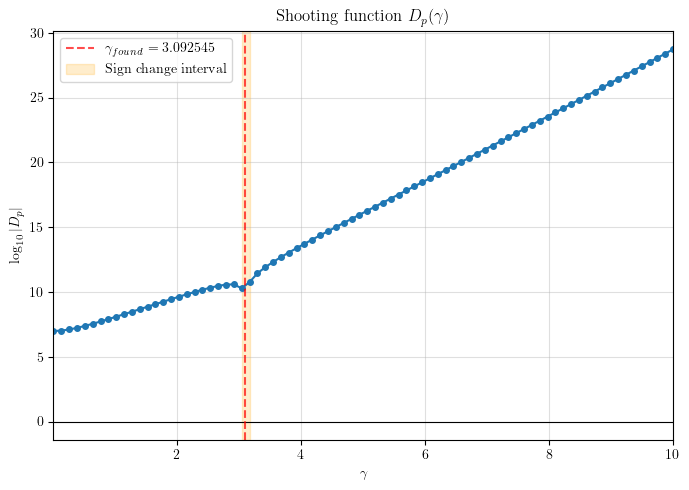


Shooting function verification:
  Found γ = 3.092545
  Sign change bracket: [3.044937, 3.171392]
  γ is within bracket: True
  D_p(γ_found) ≈ 9.734435e+09
  |D_p(γ_found)| < 1e-3: False


In [7]:
# Diagnostic: gamma from negative mode (and optional D_p shooting if available)
# Run the cell above first (negative mode) to get unstable_mode; then this cell shows gamma (or D_p curve).

from Bubble_finder.ansatz_bubble import plot_Dp_shooting_verification

plot_Dp_shooting_verification(unstable_mode, show_plot=True)

## 4. Two-dimensional ansätze: clean and anchored

Visual **ansatz gallery**: we build several **non-oscillatory** ansatz types (same families scanned in section 5) with fixed representative parameters, and compare them side-by-side. Twisted BC only; no oscillatory negative-mode kick.



In [8]:
# ============================================================================
# Section 4: Ansatz gallery — non-oscillatory families with diagnostics
# ============================================================================
# Uses: omega_tilde, r_bubble_Q, phi_bubble_Q, rho_hom from "Homogeneous charge".
# Twisted BC only. No oscillatory exp(±iγτ) kick.

from Bubble_finder.diagnostics_sanity import build_tau_independent_embedding, residual_report_compact
from Bubble_finder.ansatz_bubble import (
    AnsatzParams, build_seed_bubble, build_twisted_seed_from_static,
    make_q_ball_objects, make_bubble_profile_1d_from_arrays,
)
from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver
from Q_ball_finder.grid import build_grid

NR_DEFAULT = 80
NTAU_DEFAULT = 100
Lr_sel = max(3.0, float(r_bubble_Q[-1]))
beta_sel = 20
rho0_s4 = float(rho_hom)
r_1d_s4 = np.asarray(r_bubble_Q, float)
phi_1d_s4 = np.asarray(phi_bubble_Q, float)

settings_s4 = Bubble2DSettings(
    Nr=NR_DEFAULT, Ntau=NTAU_DEFAULT, Lr=Lr_sel, beta=beta_sel,
    omega_ref=OMEGA, rho0=rho0_s4, rho0_bracket=(1.0, 1.1),
    newton_tol=1e-8, newton_max_iter=35, damping=0.5,
    newton_verbose=False, tau_bc="twisted",
)
solver_s4 = Bubble2DSolver(settings_s4, U, dU, d2U)
solver_s4.omega = OMEGA
solver_s4.rho0 = rho0_s4
grid2d, fields, potential, _, _ = make_q_ball_objects(solver_s4)
grid_2d = build_grid(Nr=NR_DEFAULT, Ntau=NTAU_DEFAULT, Lr=Lr_sel, beta=beta_sel)
bubble_profile_1d = make_bubble_profile_1d_from_arrays(r_1d_s4, phi_1d_s4)

def _eval_ansatz(solver, x0, name=""):
    """Residual norms, tau_std_rho from rho=sqrt(Re(phi_rot*phibar_rot)), boundary flag."""
    rep = residual_report_compact(solver, x0, name=name)
    j_max, i_max = rep.get("j_max", 0), rep.get("i_max", 0)
    at_boundary = (j_max == 0 or j_max == solver.Nr - 1 or i_max == 0 or i_max == solver.Nt - 1)
    rep["at_boundary"] = at_boundary
    y, ybar = solver.unpack(x0)
    phi_rot, phibar_rot = solver.phi_rot(y, ybar)
    u = np.maximum((phi_rot * phibar_rot).real, 0.0)
    rho = np.sqrt(u)
    rep["tau_std_rho"] = float(np.max(np.std(rho, axis=1))) if rho.size > 0 else 0.0
    rep["rho"] = rho
    rep["x0"] = x0
    return rep

# Build tau bump for twisted_from_static (localized near tau~0)
Nr, Nt = solver_s4.Nr, solver_s4.Nt
r_arr = np.asarray(solver_s4.grid.r, float)
tau_arr = np.asarray(solver_s4.grid.tau, float)
rr = np.asarray(r_arr, float).reshape(-1, 1)  # (Nr, 1)
tt = np.asarray(tau_arr, float).reshape(1, -1)  # (1, Nt)
sigma_r, sigma_tau = 2.0, 0.15 * max(abs(tau_arr[-1] - tau_arr[0]), 0.1)
r_c, tau_c = float(np.median(rr)), float(tau_arr[0])
bump = np.exp(-((rr - r_c)**2) / (2*sigma_r**2)) * np.exp(-((tt - tau_c)**2) / (2*sigma_tau**2))
bump_y = rr * bump
bump_ybar = -0.5 * bump_y.copy()
seed_tau_bump = (bump_y, bump_ybar)

# ANSATZ_FAMILIES: non-oscillatory (static, twisted_from_static, gated_bubble)
gallery = []

# 1) Static embedded
x_static = build_tau_independent_embedding(solver_s4, r_1d_s4, phi_1d_s4, rho0_s4)
rep = _eval_ansatz(solver_s4, x_static, "static_embedded")
rep["name"] = "static_embedded"
rep["params"] = {}
gallery.append(rep)

# 2) Twisted from static (tau bump, a=0.05)
x_tw = build_twisted_seed_from_static(solver=solver_s4, r_1d=r_1d_s4, phi_1d=phi_1d_s4, rho0=rho0_s4,
    a=0.05, seed_tau_bump=seed_tau_bump)
rep = _eval_ansatz(solver_s4, x_tw, "twisted_from_static")
rep["name"] = "twisted_from_static"
rep["params"] = {"a": 0.05}
gallery.append(rep)

# 3) Gated bubble (build_seed_bubble with eps=0; no oscillatory kick)
params_gated = AnsatzParams(eps=0.0, k=1, phase=0.0, amp=1.0, tau_gate_frac=0.15, r_window_frac=0.15)
neg_mode_dummy = (np.zeros_like(fields.grid.r), np.zeros_like(fields.grid.r), 0.0)
try:
    x0_g, _ = build_seed_bubble(
        grid=fields.grid, fields=fields, potential=potential,
        omega_ref=OMEGA, omega_tilde=omega_tilde,
        bubble_profile_1d=bubble_profile_1d, params=params_gated,
        neg_mode_override=neg_mode_dummy,
    )
    rep = _eval_ansatz(solver_s4, x0_g, "gated_bubble")
    rep["name"] = "gated_bubble"
    rep["params"] = {"amp": 1.0, "tau_gate_frac": 0.15}
    gallery.append(rep)
except Exception as e:
    print(f"gated_bubble build failed: {e}")

# Sort by nF_inf for summary
gallery.sort(key=lambda g: g["nF_inf"])
print("Ansatz gallery built. Summary (by ||F||_inf):")
for g in gallery:
    print(f"  {g['name']:<22} ||F||_inf={g['nF_inf']:.4e} tau_std_rho={g['tau_std_rho']:.4e} boundary={g['at_boundary']}")


Ansatz gallery built. Summary (by ||F||_inf):
  static_embedded        ||F||_inf=3.1325e-01 tau_std_rho=6.6613e-16 boundary=True
  gated_bubble           ||F||_inf=2.2948e+00 tau_std_rho=4.4994e-01 boundary=False
  twisted_from_static    ||F||_inf=1.9080e+01 tau_std_rho=3.7733e-03 boundary=True


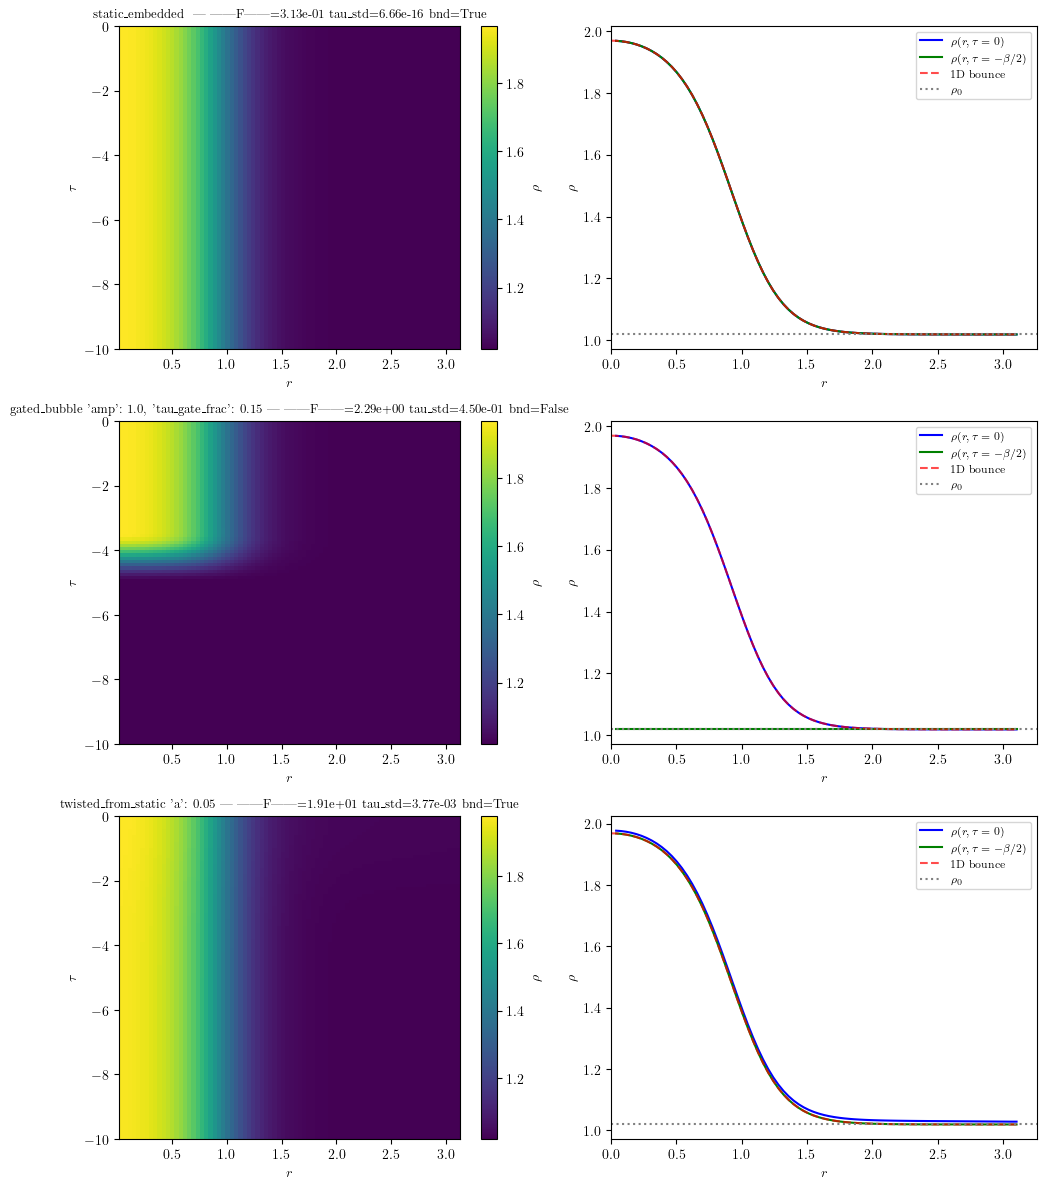


Ansatz gallery summary (sorted by ||F||_inf):
name                   params                      ||F||_inf ||F||_2/sqrt(N)  tau_std_rho boundary
static_embedded        {}                         3.1325e-01     1.3449e-01   6.6613e-16     True
gated_bubble           {'amp': 1.0, 'tau_gate     2.2948e+00     1.8117e-01   4.4994e-01    False
twisted_from_static    {'a': 0.05}                1.9080e+01     8.7288e-01   3.7733e-03     True


In [11]:
# Plot gallery: heatmap + slices for each ansatz
r_plot = np.asarray(solver_s4.grid.r, float)
tau_plot = np.asarray(solver_s4.grid.tau, float)
beta_s4 = float(solver_s4.settings.beta)
n_ansatz = len(gallery)
fig, axes = plt.subplots(n_ansatz, 2, figsize=(10, 4 * n_ansatz))
if n_ansatz == 1:
    axes = axes.reshape(1, -1)
for row, g in enumerate(gallery):
    rho_a = g["rho"]
    # Ansatz card
    card = f"{g['name']} {g['params']} | ||F||={g['nF_inf']:.2e} tau_std={g['tau_std_rho']:.2e} bnd={g['at_boundary']}"
    axes[row, 0].set_title(card, fontsize=9)
    im = axes[row, 0].pcolormesh(r_plot, tau_plot, rho_a.T, shading="auto", cmap="viridis")
    axes[row, 0].set_xlabel(r"$r$")
    axes[row, 0].set_ylabel(r"$\tau$")
    axes[row, 0].set_aspect("auto")
    plt.colorbar(im, ax=axes[row, 0], label=r"$\rho$")
    axes[row, 1].plot(r_plot, rho_a[:, 0], "b-", label=r"$\rho(r,\tau=0)$")
    axes[row, 1].plot(r_plot, rho_a[:, -1], "g-", label=r"$\rho(r,\tau=-\beta/2)$")
    axes[row, 1].plot(r_1d_s4, phi_1d_s4, "r--", alpha=0.7, label="1D bounce")
    axes[row, 1].axhline(rho0_s4, color="gray", ls=":", label=r"$\rho_0$")
    axes[row, 1].set_xlabel(r"$r$")
    axes[row, 1].set_ylabel(r"$\rho$")
    axes[row, 1].legend(fontsize=8)
    axes[row, 1].set_xlim(0, None)
plt.tight_layout()
plt.show()

# Summary table
print("\nAnsatz gallery summary (sorted by ||F||_inf):")
print(f"{'name':<22} {'params':<24} {'||F||_inf':>12} {'||F||_2/sqrt(N)':>14} {'tau_std_rho':>12} {'boundary':>8}")
for g in gallery:
    ps = str(g.get("params", {}))[:22]
    print(f"{g['name']:<22} {ps:<24} {g['nF_inf']:>12.4e} {g['nF_2_per_site']:>14.4e} {g['tau_std_rho']:>12.4e} {str(g['at_boundary']):>8}")


In [10]:
# (Legacy slice plot removed; ansatz gallery plots above replace this.)
pass


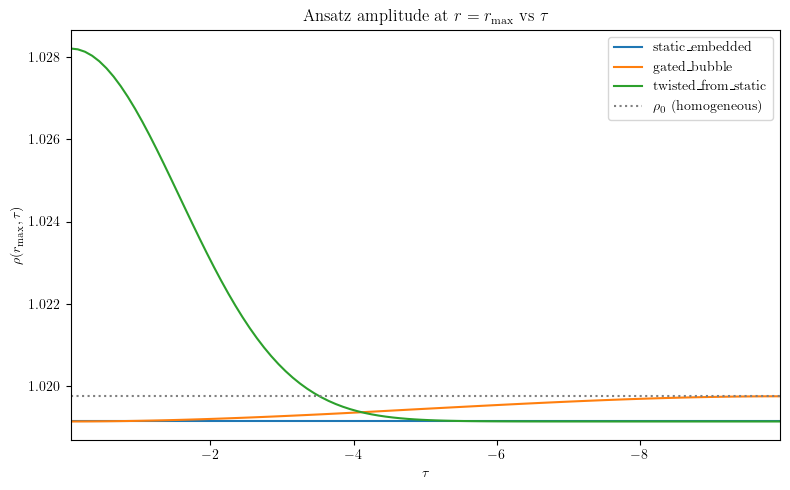

In [12]:
# ρ(r=r_max, τ) vs τ for each ansatz: temporal dependence at the boundary
tau_plot = np.asarray(solver_s4.grid.tau, float)
r_max = float(solver_s4.grid.r[-1])
fig, ax = plt.subplots(figsize=(8, 5))
for g in gallery:
    rho_at_rmax = g["rho"][-1, :]
    ax.plot(tau_plot, rho_at_rmax, lw=1.5, label=g["name"])
ax.axhline(rho0_s4, color="gray", ls=":", label=r"$\rho_0$ (homogeneous)")
ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$\rho(r_{\mathrm{max}}, \tau)$")
ax.set_title(r"Ansatz amplitude at $r=r_{\mathrm{max}}$ vs $\tau$")
ax.legend()
ax.set_xlim(tau_plot[0], tau_plot[-1])
plt.tight_layout()
plt.show()


## 4.5 Existence checker (pinned branch)

We check whether a **non-pinned** bounce solution exists by scanning a **pinned** branch: we augment the system with a Lagrange multiplier λ and constrain ρ at the center (j=0, first radial point) to a value ρ_pin. If λ(ρ_pin) changes sign, there exists a ρ* where λ=0, i.e. a solution with that central density and no pin — the **unpinned bounce**.

- **Scan**: solve the augmented system for a range of ρ_pin ∈ [ρ0, ρ_true]; record λ and ||F||.
- **Refine**: if λ changes sign, bisect to find ρ* with λ≈0 and recover the bounce field.

[ExistenceScan] pin_site=(1, 0), anchor_site=(1, 1), anchor_which=y_re
[ExistenceScan] rho_seed(pin_site) = 2.05491
[ExistenceScan] reordered=False, ramp_steps=12, total_points=22
[ExistenceScan] k   rho_pin        lambda        ||F||     ok  iters  alpha
      [Newton] it=01  ||F||=1.917e+04  lambda=+0.000e+00  alpha=1.00e+00
      [Newton] it=02  ||F||=1.678e+04  lambda=+7.918e+01  alpha=1.25e-01
      [Newton] it=03  ||F||=4.549e+02  lambda=+4.246e+02  alpha=1.00e+00
      [Newton] it=04  ||F||=4.365e+02  lambda=+4.349e+02  alpha=3.12e-02
      [Newton] it=05  ||F||=3.101e+02  lambda=+4.684e+02  alpha=2.50e-01
      [Newton] it=06  ||F||=1.434e+02  lambda=+4.982e+02  alpha=5.00e-01
      [Newton] it=07  ||F||=8.341e+00  lambda=+5.194e+02  alpha=1.00e+00
      [Newton] it=08  ||F||=1.050e-01  lambda=+5.181e+02  alpha=1.00e+00
      [Newton] it=09  ||F||=2.222e-05  lambda=+5.181e+02  alpha=1.00e+00
      [Newton] it=10  ||F||=2.502e-11  lambda=+5.181e+02  alpha=1.00e+00
[ExistenceScan

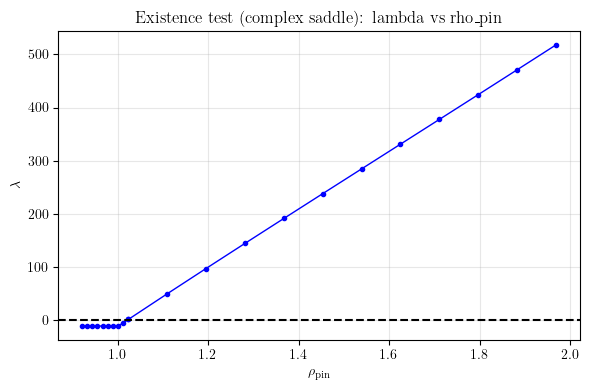

Unpinned residual ||F|| = 2.066293e-09


RuntimeError: latex was not able to process the following string:
b'Slice at \\u03c4=0 (unpinned candidate)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.26 (MiKTeX 24.12) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2024-06-01> patch level 2
L3 programming layer <2024-08-16>
(/home/giulio/.miktex/texmfs/install/tex/latex/base/article.cls
Document Class: article 2024/02/08 v1.4n Standard LaTeX document class
(/home/giulio/.miktex/texmfs/install/tex/latex/base/size10.clo))
(/home/giulio/.miktex/texmfs/install/tex/latex/type1cm/type1cm.sty)
(/home/giulio/.miktex/texmfs/install/tex/latex/cm-super/type1ec.sty
(/home/giulio/.miktex/texmfs/install/tex/latex/base/t1cmr.fd))
(/home/giulio/.miktex/texmfs/install/tex/latex/base/inputenc.sty)
(/home/giulio/.miktex/texmfs/install/tex/latex/geometry/geometry.sty
(/home/giulio/.miktex/

Error in callback <function _draw_all_if_interactive at 0x7750e77832e0> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: latex was not able to process the following string:
b'Slice at \\u03c4=0 (unpinned candidate)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.26 (MiKTeX 24.12) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2024-06-01> patch level 2
L3 programming layer <2024-08-16>
(/home/giulio/.miktex/texmfs/install/tex/latex/base/article.cls
Document Class: article 2024/02/08 v1.4n Standard LaTeX document class
(/home/giulio/.miktex/texmfs/install/tex/latex/base/size10.clo))
(/home/giulio/.miktex/texmfs/install/tex/latex/type1cm/type1cm.sty)
(/home/giulio/.miktex/texmfs/install/tex/latex/cm-super/type1ec.sty
(/home/giulio/.miktex/texmfs/install/tex/latex/base/t1cmr.fd))
(/home/giulio/.miktex/texmfs/install/tex/latex/base/inputenc.sty)
(/home/giulio/.miktex/texmfs/install/tex/latex/geometry/geometry.sty
(/home/giulio/.miktex/

RuntimeError: latex was not able to process the following string:
b'Slice at \\u03c4=0 (unpinned candidate)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.26 (MiKTeX 24.12) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2024-06-01> patch level 2
L3 programming layer <2024-08-16>
(/home/giulio/.miktex/texmfs/install/tex/latex/base/article.cls
Document Class: article 2024/02/08 v1.4n Standard LaTeX document class
(/home/giulio/.miktex/texmfs/install/tex/latex/base/size10.clo))
(/home/giulio/.miktex/texmfs/install/tex/latex/type1cm/type1cm.sty)
(/home/giulio/.miktex/texmfs/install/tex/latex/cm-super/type1ec.sty
(/home/giulio/.miktex/texmfs/install/tex/latex/base/t1cmr.fd))
(/home/giulio/.miktex/texmfs/install/tex/latex/base/inputenc.sty)
(/home/giulio/.miktex/texmfs/install/tex/latex/geometry/geometry.sty
(/home/giulio/.miktex/

<Figure size 1000x400 with 3 Axes>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Se hai sostituito Bubble_finder/bounce_existence.py:
from Bubble_finder.bounce_existence import existence_driver
# Altrimenti, se tieni il file nuovo con nome diverso:
# from Bubble_finder.bounce_existence_complex import existence_driver

from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver, solve_rho0_for_omega

# 1) Build solver on the same grid as section 4 (requires grid_2d from section 4)
Lr_ex = grid_2d.dr * grid_2d.Nr
beta_ex = 2.0 * abs(grid_2d.tau[-1])
Ntau_ex = getattr(grid_2d, "Ntau", len(grid_2d.tau))

settings_exist = Bubble2DSettings(
    Nr=grid_2d.Nr,
    Ntau=Ntau_ex,
    Lr=Lr_ex,
    beta=beta_ex,
    omega_ref=OMEGA,
    rho0_bracket=(1.0, 1.1),
    newton_tol=1e-10,
    newton_max_iter=40,        # <<< importante
    tau_bc="twisted",
    eta0=beta_ex * (omega_tilde - OMEGA),
    damping=1.0,
    verbose=True,
    newton_verbose=True,
    complex_saddle=True,       # <<< fondamentale
)

solver_exist = Bubble2DSolver(settings_exist, U, dU, d2U)
solver_exist.omega = OMEGA
solver_exist.rho0 = float(solve_rho0_for_omega(OMEGA, solver_exist.dU, settings_exist.rho0_bracket))

# 2) Seed (come prima; deve produrre un vettore in rappresentazione solver, cioè RI-split)
phi_false, phi_true = vacua_of_Omega(phi0=PHI0, v1=V1, v2=V2, omega=OMEGA, verbose=False)
x0_fields = solver_exist.build_anchored_initial_guess(rho_center=float(phi_true), Rb=4.0, Lw=0.5)
x0_fields = solver_exist.to_fields_vector(x0_fields)  # converte 2-field -> RI se serve

# 3) Pin/Anchor sites (evita j=1)
pin_site    = (1, 0)
anchor_site = (1, 1)        # evita i=0 per l’equazione liberata
anchor_which = "y_re"

rho_hom = float(solver_exist.rho0)

# Scan "moderato" iniziale: dal background verso valori un po' più bassi
# (se vuoi spingerti più giù, estendi la seconda estremità a rho_hom*0.7, ecc.)
rho_min = max(rho_hom * 0.90, 1e-6)
rho_pin_values = np.linspace(rho_hom * (1.0 - 1e-4), rho_min, 10)

# 4) Run existence driver
out = existence_driver(
    solver_exist,
    rho_pin_values=rho_pin_values,
    x0_fields=x0_fields,
    pin_site=pin_site,
    anchor_site=anchor_site,
    anchor_which=anchor_which,
    homotopy_steps=12,
    verbose=True,
    newton_verbose=True,
)

print("out['exists'] =", out["exists"])

# 5) Plot lambda vs rho_pin (anche se non ha crossing, è diagnostico)
scan = out["scan"]
rho_plot = np.array([p.rho_pin for p in scan.points])
lam_plot = np.array([p.lambda_pin for p in scan.points])

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(rho_plot, lam_plot, "b-o", lw=1, ms=3)
ax.axhline(0, color="k", ls="--")
ax.set_xlabel(r"$\rho_{\rm pin}$")
ax.set_ylabel(r"$\lambda$")
ax.set_title("Existence test (complex saddle): lambda vs rho_pin")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6) If refined candidate exists: verify and plot rho(r,tau)
if out["exists"] and out.get("refined") is not None:
    N_fields = solver_exist.system_size_fields()
    x_fields_star = out["refined"]["x_aug_star"][:N_fields]

    nF = np.linalg.norm(solver_exist.residual_fields(x_fields_star))
    print(f"Unpinned residual ||F|| = {nF:.6e}")

    y_star, ybar_star = solver_exist.unpack(x_fields_star)
    rho_map = solver_exist.rho_map(y_star, ybar_star)

    R_plot = solver_exist.grid.r
    T_plot = solver_exist.grid.tau
    Rg, Tg = np.meshgrid(R_plot, T_plot, indexing="xy")

    fig2, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(R_plot, rho_map[:, 0], "b-", lw=2, label=r"$\rho(r,\tau=0)$")
    axes[0].set_xlabel(r"$r$")
    axes[0].set_ylabel(r"$\rho$")
    axes[0].set_title(r"Slice at $\tau=0$ (unpinned candidate)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    cf = axes[1].pcolormesh(Rg, Tg, rho_map.T, shading="auto", cmap="viridis")
    axes[1].set_xlabel(r"$r$")
    axes[1].set_ylabel(r"$\tau$")
    axes[1].set_title(r"$\rho(r,\tau)$")
    plt.colorbar(cf, ax=axes[1], label=r"$\rho$")
    plt.tight_layout()
    plt.show()
else:
    print("No candidate found in this scan. Se lambda non cambia segno, estendi rho_min (es. 0.85, 0.8, 0.7)*rho_hom o prova anchor_which='yb_re' / 'y_im'.")


[Candidate metrics] rho_min=1.019755 rho_max=1.019755 std=1.295e-13 tau_var@r1=3.596e-12 r_var@tau0=3.523e-12


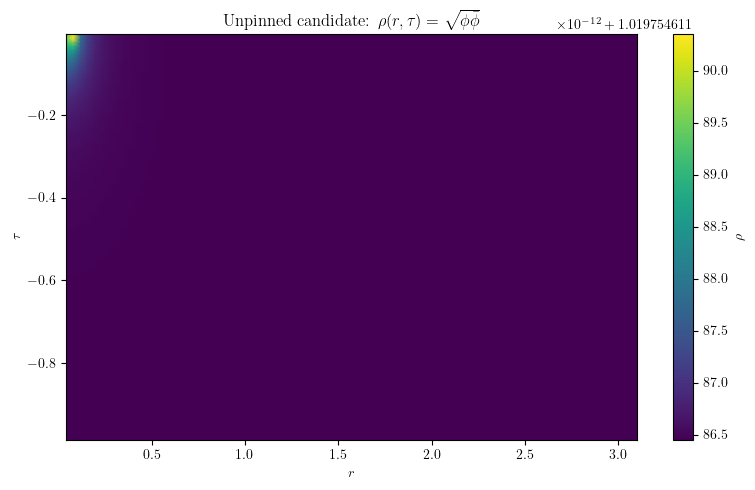

In [21]:
import numpy as np
import matplotlib.pyplot as plt

solver = solver_exist  # usa il tuo solver
g = solver.grid
N_fields = solver.system_size_fields()

def unpack_to_phi(x_fields):
    y, ybar = solver.unpack(x_fields)
    # prova a ricostruire (se esiste in API); altrimenti usa rho_map direttamente
    if hasattr(solver, "reconstruct"):
        phi, phibar = solver.reconstruct(y, ybar)
        rho = np.sqrt(np.maximum((phi * phibar).real, 0.0))
        return phi, phibar, rho
    else:
        rho = solver.rho_map(y, ybar)
        return None, None, rho

def plot_rho(rho, title):
    R, T = np.meshgrid(g.r, g.tau, indexing="xy")
    fig, ax = plt.subplots(figsize=(8,5))
    cf = ax.pcolormesh(R, T, rho.T, shading="gouraud", cmap="viridis")
    ax.set_xlabel(r"$r$")
    ax.set_ylabel(r"$\tau$")
    ax.set_title(title)
    fig.colorbar(cf, ax=ax, label=r"$\rho$")
    plt.tight_layout()
    plt.show()

def homogeneity_metrics(rho):
    # quanto varia nello spazio?
    rho_min, rho_max = float(np.min(rho)), float(np.max(rho))
    rho_std = float(np.std(rho))
    # variazione lungo tau a r fissato (prendi r index 1 per evitare singolarità)
    dr_tau = float(np.max(np.abs(rho[1,:] - np.mean(rho[1,:]))))
    # variazione lungo r a tau=0
    dt_r = float(np.max(np.abs(rho[:,0] - np.mean(rho[:,0]))))
    return rho_min, rho_max, rho_std, dr_tau, dt_r

# --- prendi la soluzione unpinned trovata dal refine (quella con lambda~0) ---
x_fields_star = out["refined"]["x_aug_star"][:N_fields].copy()

_, _, rho_star = unpack_to_phi(x_fields_star)
m = homogeneity_metrics(rho_star)
print(f"[Candidate metrics] rho_min={m[0]:.6f} rho_max={m[1]:.6f} std={m[2]:.3e} "
      f"tau_var@r1={m[3]:.3e} r_var@tau0={m[4]:.3e}")

plot_rho(rho_star, r"Unpinned candidate: $\rho(r,\tau)=\sqrt{\phi\bar\phi}$")


In [25]:
import numpy as np

solver = solver_exist
N_fields = solver.system_size_fields()

pts = out["scan"].points  # lista di point

def get_attr(p, name, default=None):
    return p.get(name, default) if isinstance(p, dict) else getattr(p, name, default)

def get_solution_fields(p):
    """
    Ritorna x_fields (size N_fields) partendo da:
    - p.x_aug (droppando lambda) oppure
    - p.x_fields
    """
    x_aug = get_attr(p, "x_aug", None)
    if x_aug is not None:
        x_aug = np.asarray(x_aug, dtype=float)
        return x_aug[:N_fields].copy()

    x_fields = get_attr(p, "x_fields", None)
    if x_fields is not None:
        x_fields = np.asarray(x_fields, dtype=float)
        return x_fields[:N_fields].copy()

    return None

# --- scegli seed pinned vicino al target ---
target = 1.965831

candidates = []
for p in pts:
    rho = get_attr(p, "rho_pin", np.nan)
    x0 = get_solution_fields(p)
    if x0 is not None and np.isfinite(rho):
        candidates.append((abs(rho - target), rho, p, x0))

if len(candidates) == 0:
    raise RuntimeError("Nessun punto nello scan contiene x_aug o x_fields. Il driver non sta salvando le soluzioni nei points.")

candidates.sort(key=lambda t: t[0])
_, rho_pin, p0, x0_fields = candidates[0]

lam = get_attr(p0, "lambda_pin", np.nan)
print(f"Using pinned seed: rho_pin={rho_pin:.6f}, lambda={lam:+.3e}")

# --- Newton unpinned ---
if "newton_unpinned" not in globals():
    raise RuntimeError("Non trovo newton_unpinned() nel notebook. Definisci prima quella funzione (è quella che usavi per l'unpinned).")

x_sol, info = newton_unpinned(
    solver,
    x0_fields,
    tol=1e-8,
    accept_tol=4e-8,
    max_iter=40,
    verbose=True
)

nF = np.linalg.norm(solver.residual_fields(x_sol))
print(f"[Unpinned-from-pinned] ||F|| = {nF:.3e}")


Using pinned seed: rho_pin=1.968920, lambda=+5.181e+02
[Unpinned Newton] iter=0  ||F||=5.181e+02
[Unpinned Newton] iter= 1  alpha=1  ||F||=2.639e+00
[Unpinned Newton] iter= 2  alpha=1  ||F||=1.124e-02
[Unpinned Newton] iter= 3  alpha=1  ||F||=7.345e-07
[Unpinned Newton] iter= 4  alpha=1  ||F||=2.232e-11
[Unpinned-from-pinned] ||F|| = 2.232e-11


rho min/max = 1.01975 / 1.01975  |  range = 1.11022e-15


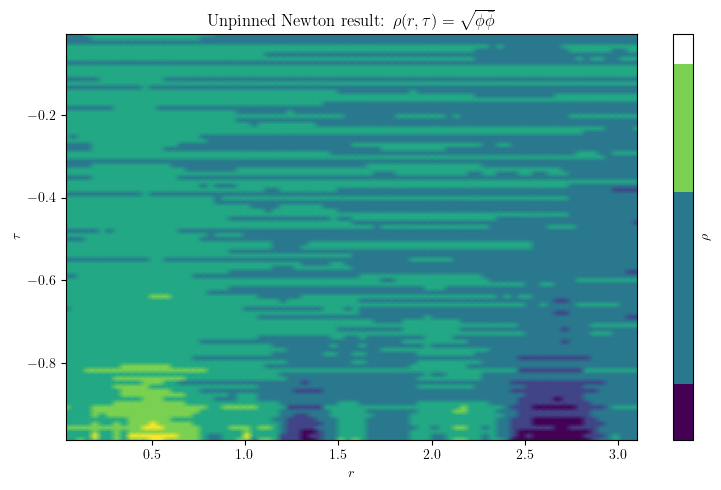

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from Bubble_finder.ansatz_bubble import make_q_ball_objects

# --- input: soluzione Newton unpinned ---
solver = solver_exist
x_fields = np.asarray(x_sol)

# --- costruisci l'oggetto "fields" coerente con solver (come nella cella ansatz) ---
# (make_q_ball_objects restituisce: grid, fields, potential, ..., ...)
_, fields, _, _, _ = make_q_ball_objects(solver)

# --- attenzione: se x_sol è già "fields-vector" (dimensione fields.system_size_fields), ok.
# Se invece contiene anche extra variabili (es. lambda), taglia.
N_fields = fields.system_size_fields() if hasattr(fields, "system_size_fields") else solver.system_size_fields()
if x_fields.size != N_fields:
    x_fields = x_fields[:N_fields].copy()

# --- ricostruisci phi, phibar ESATTAMENTE come fai per l'ansatz ---
y, ybar = fields.unpack(x_fields)
phi, phibar = fields.reconstruct(y, ybar)

# --- rho = sqrt((phi phibar).real) ---
rho = np.sqrt(np.maximum((phi * phibar).real, 0.0))

# diagnostica minima (ti dice subito se è "quasi costante")
print(f"rho min/max = {rho.min():.6g} / {rho.max():.6g}  |  range = {(rho.max()-rho.min()):.6g}")

# --- plot nello stile che vuoi ---
g = fields.grid
R, T = np.meshgrid(g.r, g.tau, indexing="xy")

fig, ax = plt.subplots(figsize=(8, 5))
cf = ax.pcolormesh(R, T, rho.T, shading="gouraud", cmap="viridis")
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$\tau$")
ax.set_title(r"Unpinned Newton result: $\rho(r,\tau)=\sqrt{\phi\bar\phi}$")
fig.colorbar(cf, ax=ax, label=r"$\rho$")
plt.tight_layout()
plt.show()


---- quick diagnostics ----
|phi|   min/max = 0.584547 / 1.01691
|phibar|min/max = 1.02261 / 1.77898
cross rho=min/max = 1.01975 / 1.01975
conjugacy |phibar-phi*|  min/max = 5.703e-03 / 1.194e+00
at pin_site (1, 0): |phi|=1.01691, |phibar|=1.02261, cross=1.01975
at r=0,tau=0:            |phi|=1.01691, |phibar|=1.02261, cross=1.01975
at r=rmax,tau=0:         |phi|=1.01691, |phibar|=1.02261, cross=1.01975


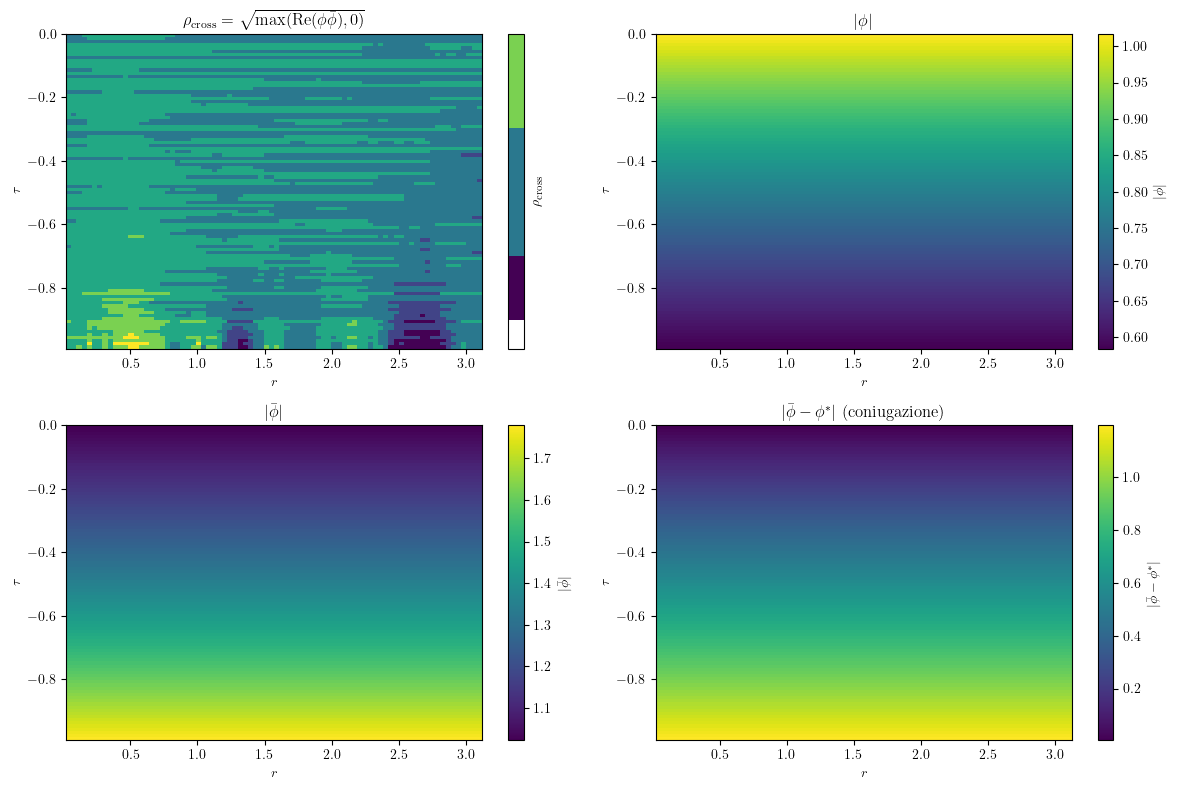

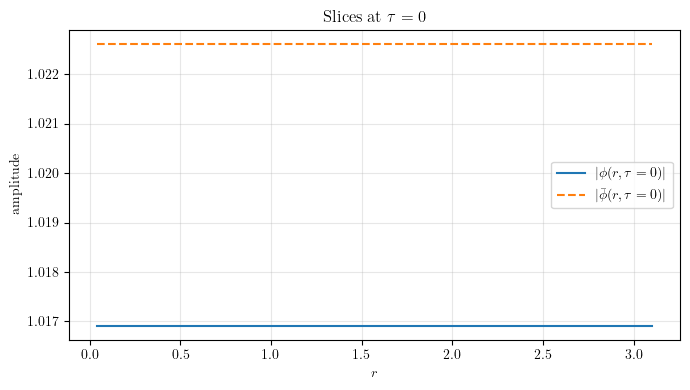

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from Bubble_finder.ansatz_bubble import make_q_ball_objects

# --- input ---
solver = solver_exist
x_fields = np.asarray(x_sol)

# se avevi un pin_site, mettilo qui (i_r, j_tau)
pin_site = (1, 0)   # cambia se usi un altro
i_pin, j_pin = pin_site

# --- ricostruisci campi come nella cella ansatz ---
_, fields, _, _, _ = make_q_ball_objects(solver)

N_fields = fields.system_size_fields() if hasattr(fields, "system_size_fields") else solver.system_size_fields()
if x_fields.size != N_fields:
    x_fields = x_fields[:N_fields].copy()

y, ybar = fields.unpack(x_fields)
phi, phibar = fields.reconstruct(y, ybar)

g = fields.grid
Nr, Nt = len(g.r), len(g.tau)

# --- helper: porta qualunque array (Nr,Nt) o (Nt,Nr) in forma (Nt,Nr) per pcolormesh ---
def as_TNr(A):
    A = np.asarray(A)
    if A.shape == (Nr, Nt):
        return A.T
    if A.shape == (Nt, Nr):
        return A
    raise ValueError(f"shape non compatibile: {A.shape} vs (Nr,Nt)=({Nr},{Nt})")

# --- quantità diagnostiche ---
rho_cross = np.sqrt(np.maximum((phi * phibar).real, 0.0))     # quello che stavi plottando
rho_phi   = np.abs(phi)                                      # più sensato
rho_phib  = np.abs(phibar)
conj_mis  = np.abs(phibar - np.conjugate(phi))               # =0 se phibar≈phi*

# stampa numeri chiave
print("---- quick diagnostics ----")
print(f"|phi|   min/max = {rho_phi.min():.6g} / {rho_phi.max():.6g}")
print(f"|phibar|min/max = {rho_phib.min():.6g} / {rho_phib.max():.6g}")
print(f"cross rho=min/max = {rho_cross.min():.6g} / {rho_cross.max():.6g}")
print(f"conjugacy |phibar-phi*|  min/max = {conj_mis.min():.3e} / {conj_mis.max():.3e}")

# valori in punti chiave
print(f"at pin_site {pin_site}: |phi|={rho_phi[i_pin,j_pin]:.6g}, |phibar|={rho_phib[i_pin,j_pin]:.6g}, cross={rho_cross[i_pin,j_pin]:.6g}")
print(f"at r=0,tau=0:            |phi|={rho_phi[0,0]:.6g}, |phibar|={rho_phib[0,0]:.6g}, cross={rho_cross[0,0]:.6g}")
print(f"at r=rmax,tau=0:         |phi|={rho_phi[-1,0]:.6g}, |phibar|={rho_phib[-1,0]:.6g}, cross={rho_cross[-1,0]:.6g}")

# --- griglia per plot ---
R, T = np.meshgrid(g.r, g.tau, indexing="xy")

# --- plot 2x2: cross, |phi|, |phibar|, mismatch coniugazione ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

A = as_TNr(rho_cross)
cf = axes[0,0].pcolormesh(R, T, A, shading="auto", cmap="viridis")
axes[0,0].set_title(r"$\rho_{\rm cross}=\sqrt{\max(\mathrm{Re}(\phi\bar\phi),0)}$")
axes[0,0].set_xlabel(r"$r$"); axes[0,0].set_ylabel(r"$\tau$")
fig.colorbar(cf, ax=axes[0,0], label=r"$\rho_{\rm cross}$")

A = as_TNr(rho_phi)
cf = axes[0,1].pcolormesh(R, T, A, shading="auto", cmap="viridis")
axes[0,1].set_title(r"$|\phi|$")
axes[0,1].set_xlabel(r"$r$"); axes[0,1].set_ylabel(r"$\tau$")
fig.colorbar(cf, ax=axes[0,1], label=r"$|\phi|$")

A = as_TNr(rho_phib)
cf = axes[1,0].pcolormesh(R, T, A, shading="auto", cmap="viridis")
axes[1,0].set_title(r"$|\bar\phi|$")
axes[1,0].set_xlabel(r"$r$"); axes[1,0].set_ylabel(r"$\tau$")
fig.colorbar(cf, ax=axes[1,0], label=r"$|\bar\phi|$")

A = as_TNr(conj_mis)
cf = axes[1,1].pcolormesh(R, T, A, shading="auto", cmap="viridis")
axes[1,1].set_title(r"$|\bar\phi-\phi^\ast|$ (coniugazione)")
axes[1,1].set_xlabel(r"$r$"); axes[1,1].set_ylabel(r"$\tau$")
fig.colorbar(cf, ax=axes[1,1], label=r"$|\bar\phi-\phi^\ast|$")

plt.tight_layout()
plt.show()

# --- slice a tau=0 per capire subito se è una bolla in r ---
tau0_idx = 0
plt.figure(figsize=(7,4))
plt.plot(g.r, rho_phi[:, tau0_idx], label=r"$|\phi(r,\tau=0)|$")
plt.plot(g.r, rho_phib[:, tau0_idx], "--", label=r"$|\bar\phi(r,\tau=0)|$")
plt.xlabel(r"$r$"); plt.ylabel("amplitude"); plt.title(r"Slices at $\tau=0$")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()


[x_pinned] using scan point k=2, rho_pin=1.79693510
[Unpinned Newton] iter=0  ||F||=4.603e+02
[Unpinned Newton] iter= 1  alpha=0.000977  ||F||=4.608e+02
[Unpinned Newton] iter= 2  alpha=0.000977  ||F||=2.218e+06
[Unpinned Newton] iter= 3  alpha=0.0312  ||F||=2.150e+06
[Unpinned Newton] iter= 4  alpha=0.25  ||F||=1.646e+06
[Unpinned Newton] iter= 5  alpha=0.25  ||F||=1.260e+06
[Unpinned Newton] iter= 6  alpha=0.125  ||F||=1.108e+06
[Unpinned Newton] iter= 7  alpha=0.0625  ||F||=1.040e+06
[Unpinned Newton] iter= 8  alpha=0.125  ||F||=9.395e+05
[Unpinned Newton] iter= 9  alpha=0.25  ||F||=7.229e+05
[Unpinned Newton] iter=10  alpha=1  ||F||=1.840e+05
[Unpinned Newton] iter=11  alpha=1  ||F||=5.477e+04
[Unpinned Newton] iter=12  alpha=0.0312  ||F||=5.406e+04
[Unpinned Newton] iter=13  alpha=0.25  ||F||=5.032e+04
[Unpinned Newton] iter=14  alpha=0.125  ||F||=4.743e+04
[Unpinned Newton] iter=15  alpha=0.25  ||F||=4.128e+04
[Unpinned Newton] iter=16  alpha=0.5  ||F||=2.857e+04
[Unpinned Newton

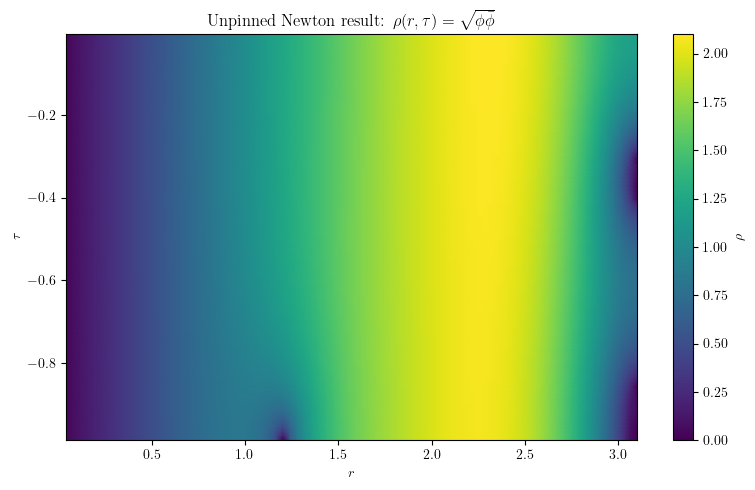

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# opzionale ma consigliato per Newton
import scipy.sparse.linalg as spla


# ============================================================
# 0) target rho_pin da cui partire (pinned) ma poi Newton unpinned
# ============================================================
rho_target = 1.8#1.01975


# ============================================================
# 1) helper: estrai x_pinned (FIELDS-ONLY) in modo robusto
#    - se esiste già x_pinned in globals: usa quello
#    - se esiste out["scan"]: prendi il punto più vicino a rho_target e usa la sua soluzione pinned
#    - altrimenti: fai un solve pinned "singolo punto" via existence_driver e prendi quello
# ============================================================
def _get_from_obj(obj, names):
    """Return first existing attribute/key in names from obj, else None."""
    for n in names:
        if hasattr(obj, n):
            val = getattr(obj, n)
            if val is not None:
                return val
        if isinstance(obj, dict) and n in obj and obj[n] is not None:
            return obj[n]
    return None

def build_x_pinned_from_scan(out_scan, rho_target):
    pts = getattr(out_scan, "points", None)
    if pts is None and isinstance(out_scan, dict):
        pts = out_scan.get("points", None)
    if pts is None or len(pts) == 0:
        raise RuntimeError("scan.points non trovato o vuoto: impossibile ricostruire x_pinned.")

    # scegli punto più vicino a rho_target
    rhos = np.array([float(_get_from_obj(p, ["rho_pin", "rho"])) for p in pts], dtype=float)
    kbest = int(np.argmin(np.abs(rhos - rho_target)))
    pbest = pts[kbest]
    print(f"[x_pinned] using scan point k={kbest}, rho_pin={rhos[kbest]:.8f}")

    # prova a prendere un vettore già "fields-only"
    x_fields = _get_from_obj(pbest, ["x_fields_star", "x_fields", "x_star_fields", "x_fields_sol"])
    if x_fields is not None:
        return np.array(x_fields, dtype=float).copy()

    # altrimenti prendi l'augmented e droppa lambda_pin (ultimo elemento)
    x_aug = _get_from_obj(pbest, ["x_aug_star", "x_aug", "x_aug_sol", "x_star_aug"])
    if x_aug is None:
        raise RuntimeError("Nel punto scan non trovo né x_fields né x_aug. Controlla cosa salva existence_driver.")
    x_aug = np.array(x_aug, dtype=float)
    if x_aug.ndim != 1 or x_aug.size < 2:
        raise RuntimeError("x_aug ha forma inattesa.")
    return x_aug[:-1].copy()


# ---- definisci/calcola x_pinned senza NameError ----
x_pinned = None

# (A) se già definito
if "x_pinned" in globals() and globals()["x_pinned"] is not None:
    x_pinned = np.array(globals()["x_pinned"], dtype=float).copy()
    print("[x_pinned] found existing global x_pinned.")

# (B) se hai un x_aug globale (augmented), usalo
elif "x_aug" in globals() and globals()["x_aug"] is not None:
    x_aug_local = np.array(globals()["x_aug"], dtype=float)
    x_pinned = x_aug_local[:-1].copy()
    print("[x_pinned] built from existing global x_aug (dropped lambda_pin).")

# (C) se hai out con scan
elif "out" in globals() and globals()["out"] is not None and globals()["out"].get("scan", None) is not None:
    x_pinned = build_x_pinned_from_scan(globals()["out"]["scan"], rho_target)

# (D) fallback: fai un solve pinned solo a rho_target (richiede solver_exist, x0_fields, pin_site, anchor_site, anchor_which)
else:
    print("[x_pinned] no globals found: running a single-point pinned solve to build x_pinned...")
    # richiede che queste variabili esistano già (dalla cella precedente)
    required = ["solver_exist", "x0_fields", "pin_site", "anchor_site", "anchor_which", "existence_driver"]
    missing = [k for k in required if k not in globals()]
    if missing:
        raise NameError(f"Mancano variabili per il fallback pinned solve: {missing}")

    out_one = existence_driver(
        solver_exist,
        rho_pin_values=np.array([rho_target], dtype=float),
        x0_fields=x0_fields,
        pin_site=pin_site,
        anchor_site=anchor_site,
        anchor_which=anchor_which,
        homotopy_steps=0,          # singolo punto, niente rampa
        verbose=True,
        newton_verbose=True,
    )
    scan_one = out_one["scan"]
    x_pinned = build_x_pinned_from_scan(scan_one, rho_target)

if x_pinned is None:
    raise RuntimeError("Non sono riuscito a costruire x_pinned.")


# ============================================================
# 2) Newton UNPINNED a partire da x_pinned (fields-only)
#    accetto anche se arrivo a ~ few × 1e-8
# ============================================================
def newton_unpinned(solver, x0, tol=1e-8, accept_tol=4e-8, max_iter=30, verbose=True):
    # usa API fields se esiste, altrimenti fallback
    Ffun = getattr(solver, "residual_fields", None)
    Jfun = getattr(solver, "jacobian_fields", None)
    if Ffun is None:
        Ffun = solver.residual
    if Jfun is None:
        Jfun = solver.jacobian

    x = np.array(x0, dtype=float).copy()
    n0 = np.linalg.norm(Ffun(x))
    if verbose:
        print(f"[Unpinned Newton] iter=0  ||F||={n0:.3e}")

    for it in range(1, max_iter + 1):
        F = Ffun(x)
        nF = np.linalg.norm(F)
        if nF <= tol:
            return x, {"ok": True, "iters": it-1, "norm": nF, "status": "converged"}

        J = Jfun(x)

        # solve J dx = -F
        try:
            dx = spla.spsolve(J, -F)
        except Exception:
            dx = np.linalg.solve(np.asarray(J), -F)

        # semplice backtracking
        alpha = 1.0
        x_try = x + alpha * dx
        n_try = np.linalg.norm(Ffun(x_try))

        # cerca riduzione
        bt = 0
        while (not np.isfinite(n_try) or n_try > nF) and alpha > 1e-3 and bt < 12:
            alpha *= 0.5
            x_try = x + alpha * dx
            n_try = np.linalg.norm(Ffun(x_try))
            bt += 1

        x = x_try
        if verbose:
            print(f"[Unpinned Newton] iter={it:2d}  alpha={alpha:.3g}  ||F||={n_try:.3e}")

        if n_try <= accept_tol:
            return x, {"ok": True, "iters": it, "norm": n_try, "status": "accepted (loose tol)"}

    nF = np.linalg.norm(Ffun(x))
    return x, {"ok": (nF <= accept_tol), "iters": max_iter, "norm": nF, "status": "max_iter"}


x_sol, info = newton_unpinned(
    solver_exist,
    x_pinned,
    tol=1e-10,          # "vera" convergenza
    accept_tol=4e-8,    # accetto anche se arrivo a ~3.9e-8
    max_iter=30,
    verbose=True,
)
print("[Unpinned Newton] info:", info)


# ============================================================
# 3) Plot come nel tuo snippet: rho(r,tau)=sqrt((phi phibar).real)
# ============================================================
example_ansatz_phi, example_ansatz_phibar = solver_exist.unpack(x_sol)
g = solver_exist.grid

rho_anchor = np.sqrt(np.maximum((example_ansatz_phi * example_ansatz_phibar).real, 0.0))
R, T = np.meshgrid(g.r, g.tau, indexing="xy")

fig, ax = plt.subplots(figsize=(8, 5))
cf = ax.pcolormesh(R, T, rho_anchor.T, shading="gouraud", cmap="viridis")
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$\tau$")
ax.set_title(r"Unpinned Newton result: $\rho(r,\tau)=\sqrt{\phi\bar{\phi}}$")
fig.colorbar(cf, ax=ax, label=r"$\rho$")
plt.tight_layout()
plt.show()


# Second try: diagnostics

In [26]:
# Second try: diagnostics — TASK A (background) and TASK B (tau-independent bubble @ eta=0)
# Checklist: A) potential convention, B) varphi=sqrt(s), C) background eq, D) eta0=0, E) r=0, F) Neumann, G) grid, H) norms, I) tau-indep
import numpy as np
from Bubble_finder.diagnostics_sanity import (
    rho0_from_homogeneous_condition,
    build_background_zero_vec,
    build_tau_independent_embedding,
    residual_report_compact,
    bulk_vs_boundary_residual,
    checklist_potential_convention,
    checklist_field_into_potential,
    checklist_eta0_for_tau_indep,
)
from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver, solve_rho0_for_omega

# --- Build diagnostic solver (eta0=0 for tau-independent bubble check) ---
solver_diag = globals().get("solver_newton") or globals().get("solver_exist") or globals().get("solver")
if solver_diag is None and "grid_2d" in globals():
    Lr_ex = grid_2d.dr * grid_2d.Nr
    beta_ex = 2.0 * abs(grid_2d.tau[-1])
    Ntau_ex = getattr(grid_2d, "Ntau", len(grid_2d.tau))
    rho0_diag = float(solve_rho0_for_omega(OMEGA, dU, (1.0, 1.1)))
    settings_diag = Bubble2DSettings(
        Nr=grid_2d.Nr, Ntau=Ntau_ex, Lr=Lr_ex, beta=beta_ex,
        omega_ref=OMEGA, rho0=rho0_diag, rho0_bracket=(1.0, 1.1),
        newton_tol=1e-9, newton_max_iter=35, damping=0.5,
        tau_bc="twisted", complex_saddle=True, eta0=0.0,  # eta0=0 for tau-indep check
    )
    solver_diag = Bubble2DSolver(settings_diag, U, dU, d2U)
    solver_diag.omega = OMEGA
    solver_diag.rho0 = rho0_diag
    print("Diagnostic solver built from grid_2d (eta0=0)")
elif solver_diag is None:
    # Fallback: build minimal diagnostic grid from 1D bounce
    from Q_ball_finder.grid import build_grid
    _Nr, _Nt, _Lr, _beta = 80, 80, float(r_bounce[-1]) if "r_bounce" in globals() and r_bounce is not None else 25.0, 50.0
    if "r_bounce" in globals() and r_bounce is not None:
        _Lr = max(_Lr, float(np.max(r_bounce)) * 1.2)
    grid_2d = build_grid(_Nr, _Nt, _Lr, _beta)
    rho0_diag = float(solve_rho0_for_omega(OMEGA, dU, (1.0, 1.1)))
    settings_diag = Bubble2DSettings(
        Nr=grid_2d.Nr, Ntau=grid_2d.Ntau, Lr=grid_2d.dr * grid_2d.Nr, beta=2.0 * abs(grid_2d.tau[-1]),
        omega_ref=OMEGA, rho0=rho0_diag, rho0_bracket=(1.0, 1.1),
        newton_tol=1e-9, tau_bc="twisted", complex_saddle=True, eta0=0.0,
    )
    solver_diag = Bubble2DSolver(settings_diag, U, dU, d2U)
    solver_diag.rho0 = rho0_diag
    print("Diagnostic solver built from minimal grid (r_bounce)")
if solver_diag is None:
    raise NameError("Need solver_newton, solver_exist, solver, grid_2d, or r_bounce to build diagnostic solver")

# Override eta0=0 for tau-independent bubble verification (TASK B, checklist D)
from dataclasses import replace
prev_omega = getattr(solver_diag, "omega", OMEGA)
prev_rho0 = getattr(solver_diag, "rho0", solver_diag.settings.rho0)
settings_eta0 = replace(solver_diag.settings, eta0=0.0)
solver_diag = Bubble2DSolver(settings_eta0, U, dU, d2U)
solver_diag.omega = prev_omega
solver_diag.rho0 = prev_rho0
print("Diagnostic solver: eta0=0 (tau-independent bubble check)")

tau_arr = np.asarray(solver_diag.grid.tau, float)
r_arr = np.asarray(solver_diag.grid.r, float)
rho0 = float(solver_diag.rho0)


Diagnostic solver: eta0=0 (tau-independent bubble check)


In [27]:
# ============================================================================
# PART 1 — Model identity report: 1D vs 2D equation comparison
# ============================================================================
from Bubble_finder.diagnostics_sanity import model_identity_report

phi0_pot = float(PHI0)  # potential parameter
v1_pot, v2_pot = float(V1), float(V2)
mi = model_identity_report(solver_diag, dU, d2U, phi0_pot, v1_pot, v2_pot)
print(mi["report"])

PART 1 — Model identity report (1D vs 2D)

(a) 2D PDE enforced by Bubble2DSolver.residual():
  - Variables: y = r*(phi_rot - rho0), ybar = r*(phibar_rot - rho0)
  - phi_rot = e^{-omega*tau}*phi, phibar_rot = e^{+omega*tau}*phibar
  - u = Re(phi_rot * phibar_rot) = Re((y_tot/r)*(ybar_tot/r)), y_tot = y + r*rho0
  - rho = sqrt(u_pos + rho_eps), u_pos = smooth_positive(u)
  - Potential: W(u) = dU(rho)/(2*rho), U(rho)=V(varphi) with varphi=rho
  - Scalar in potential: u = Re(phi_rot*phibar_rot), rho = sqrt(u)
  - Equation: Fy = y_tt + y_rr + 2*omega*y_t + (omega^2 - W)*y_tot

(b) Tau-independent (d/dtau=0), eta0=0 reduction of 2D PDE:
  - y_t=0, y_tt=0. For real phi_rot=phibar_rot: y=ybar, y_tot=r*phi.
  - y_rr = 2*phi' + r*phi'' (from y = r*(phi-rho0))
  - Fy = y_rr + A_coef*y_tot, A_coef = 2*(omega^2 - W) [FIXED for 1D match]
  - W = dU(rho)/(2*rho), so A_coef*phi = 2*omega^2*phi - dV_dphi
  - REDUCED 2D (fixed): phi'' + 2*phi'/r + 2*omega^2*phi - dV_dphi(phi) = 0

(c) ODE solved by solv

In [28]:
# ============================================================================
# TASK B — Tau-independent bubble solution @ eta=0
# ============================================================================
# Verify that embedding the 1D bounce into 2D gives a solution of Bubble2DSolver when eta=0.
print("\n" + "=" * 70)
print("Tau-independent bubble check")
print("=" * 70)

# (1) Load 1D bounce profile — MUST use same omega as solver for embedding to be a solution
omega_ref = float(getattr(solver_diag, "omega", OMEGA))
phi0_1d = float(PHI0_BOUNCE) if "PHI0_BOUNCE" in globals() else PHI0
v1_1d = float(V1_BOUNCE) if "V1_BOUNCE" in globals() else V1
v2_1d = float(V2_BOUNCE) if "V2_BOUNCE" in globals() else V2
r_max_2d = float(solver_diag.grid.r[-1]) if len(solver_diag.grid.r) > 0 else None
r_1d, phi_1d, _, _, _ = solve_bounce(phi0_1d, v1_1d, v2_1d, omega_ref, verbose=False, extend_to=r_max_2d)
if r_1d is None or phi_1d is None:
    raise RuntimeError("solve_bounce failed for omega_ref=%s. Check potential parameters." % omega_ref)
phi_1d = np.asarray(phi_1d, float)
r_1d = np.asarray(r_1d, float)
print(f"  1D profile: solve_bounce(omega={omega_ref:.6f}), varphi range [{phi_1d.min():.6f}, {phi_1d.max():.6f}]")

# (2) Embed 1D as tau-independent 2D: phi_rot(r,tau)=varphi_1d(r), phibar_rot=phi_rot
x_seed_embed = build_tau_independent_embedding(solver_diag, r_1d, phi_1d, rho0)

# (3) Evaluate residual WITHOUT Newton
rep_embed = residual_report_compact(solver_diag, x_seed_embed, name="embedded_1d")
print(f"\n  Residual on embedded 1D (no Newton):")
print(f"    ||F||_inf = {rep_embed['nF_inf']:.6e}")
print(f"    ||F||_2 / sqrt(sites) = {rep_embed['nF_2_per_site']:.6e}")
print(f"    max at j={rep_embed['j_max']}, i={rep_embed['i_max']} (r={rep_embed['r_at_max']:.4f}, tau={rep_embed['tau_at_max']:.4f})")

# Composite criterion: PASS if residual tiny OR (residual acceptable AND bulk/boundary comparable)
# Embedded residual is limited by 1D->2D interpolation and grid discretization (~1e-2 typically).
dec_embed = bulk_vs_boundary_residual(solver_diag, x_seed_embed)
ratio_bulk_bound = dec_embed["max_boundary"] / (dec_embed["max_bulk"] + 1e-30)
TOL_EMBED_TIGHT = 1e-6
TOL_EMBED_LOOSE = 0.1   # discretization/interpolation typically gives ||F|| ~ 1e-2 to few e-2
embed_residual_ok = (
    rep_embed["nF_inf"] < TOL_EMBED_TIGHT
    or (rep_embed["nF_inf"] < TOL_EMBED_LOOSE and 0.3 < ratio_bulk_bound < 3.0)
)
if embed_residual_ok:
    if rep_embed["nF_inf"] < TOL_EMBED_TIGHT:
        print(f"  --> PASS (embedded residual < {TOL_EMBED_TIGHT})")
    else:
        print(f"  --> PASS (embedded residual {rep_embed['nF_inf']:.2e} < {TOL_EMBED_LOOSE}, bulk/boundary ratio {ratio_bulk_bound:.2f} ~ 1)")
else:
    at_boundary = (rep_embed["j_max"] == 0 or rep_embed["j_max"] == solver_diag.Nr - 1 or
                   rep_embed["i_max"] == 0 or rep_embed["i_max"] == solver_diag.Nt - 1)
    print(f"  --> FAIL (residual >= {TOL_EMBED_LOOSE} or bulk/boundary mismatch). Max at boundary={at_boundary}.")
    print("  Debug: Check A) potential convention, F) Neumann BC, G) grid match. Running Newton refinement...")

# (4) Optional Newton refinement
try:
    from Bubble_finder.bounce2d import NewtonConvergenceError
except Exception:
    NewtonConvergenceError = RuntimeError
result_embed = None
try:
    result_embed = solver_diag.solve(x_seed_embed, verbose=False, store_iteration_history=False)
    print(f"\n  Newton: success={result_embed.success}, iters={result_embed.iterations}, final ||F||={result_embed.residual_norm:.6e}")
except Exception as e:
    print(f"\n  Newton did not converge: {e}")

# (5) Compare 2D to 1D profile and check tau-variance
y_f, ybar_f = solver_diag.unpack(result_embed.x if result_embed is not None else x_seed_embed)
phi_rot_f, phibar_rot_f = solver_diag.phi_rot(y_f, ybar_f)
phi_2d_tau0 = np.real(phi_rot_f[:, 0])
r_grid = np.asarray(solver_diag.grid.r, float)  # use solver grid for comparison
phi_1d_on_r = np.interp(r_grid, r_1d, phi_1d, left=phi_1d[0], right=rho0)  # beyond bubble -> rho0
max_err = float(np.max(np.abs(phi_2d_tau0 - phi_1d_on_r)))
l2_err = float(np.linalg.norm(phi_2d_tau0 - phi_1d_on_r) / (np.linalg.norm(phi_1d_on_r) + 1e-20))
tau_std = float(np.max(np.std(np.real(phi_rot_f), axis=1)))

print(f"\n  Profile comparison (tau=0 slice vs 1D):")
print(f"    max|phi_2d - phi_1d| = {max_err:.6e}")
print(f"    L2 relative error   = {l2_err:.6e}")
print(f"    tau-variance (max over r of std_tau) = {tau_std:.6e}")

TOL_PROFILE = 1e-3  # Interpolation between 1D and 2D grids
TOL_TAU = 1e-7
profile_ok = max_err < TOL_PROFILE and l2_err < TOL_PROFILE
tau_ok = tau_std < TOL_TAU
if profile_ok and tau_ok:
    print(f"  --> PASS (profile err < {TOL_PROFILE}, tau_var < {TOL_TAU})")
else:
    if not profile_ok:
        print(f"  --> FAIL: profile mismatch (max_err={max_err:.2e}, L2={l2_err:.2e}, tol={TOL_PROFILE})")
    if not tau_ok:
        print(f"  --> FAIL: tau-variance={tau_std:.2e} (tol {TOL_TAU}). Check I) tau-independence.")
    if not (profile_ok and tau_ok):
        raise AssertionError("Tau-independent bubble check failed (profile or tau-variance)")

# Charge diagnostic (apples-to-apples using 2D definition)
try:
    from Bubble_finder.observables_2d import compute_charge_tau0_ghost_2d, compute_charge_like_2d_from_1d
    r_2d_local = np.asarray(solver_diag.grid.r, float)
    Q_2d = compute_charge_tau0_ghost_2d(solver_diag, y_f, ybar_f, subtract_background=False)
    Q_1d_like_2d = compute_charge_like_2d_from_1d(r_1d, phi_1d, r_2d_local, omega_ref, rho0, subtract_background=False)
    print(f"\n  [Checklist J] Charge (2D def): Q_2d={Q_2d:.6e}, Q_1d_like_2d={Q_1d_like_2d:.6e}, |diff|={abs(Q_2d-Q_1d_like_2d):.2e}")
except Exception as e:
    print(f"\n  [Checklist J] Charge diagnostic skipped: {e}")


Tau-independent bubble check
  1D profile: solve_bounce(omega=0.600000), varphi range [1.023106, 1.950817]

  Residual on embedded 1D (no Newton):
    ||F||_inf = 1.137958e-02
    ||F||_2 / sqrt(sites) = 2.620326e-03
    max at j=19, i=0 (r=0.7758, tau=-0.0500)
  --> PASS (embedded residual 1.14e-02 < 0.1, bulk/boundary ratio 1.00 ~ 1)

Newton converged — diagnostica risultati
  Convergenza: success, iterazioni = 3
  Residuo finale ||F|| = 7.723447e-09
  Carica Q(τ[0])      = +8.385877e+01  (primo slice, tau=-Δτ/2)
  Energia E(τ=0) slice = 5.976480e+01  (su griglia τ[0])
  Energia E(τ=0) ghost = 5.976480e+01  (ricostruita a τ=0 come Q-ball)
  Sanity (η0=0): ||F||=1.940e+01, ω²−W(ρ0)=4.159e-02


  Newton: success=True, iters=3, final ||F||=7.723447e-09

  Profile comparison (tau=0 slice vs 1D):
    max|phi_2d - phi_1d| = 5.404132e-04
    L2 relative error   = 1.435372e-04
    tau-variance (max over r of std_tau) = 8.061167e-16
  --> PASS (profile err < 0.001, tau_var < 1e-07)

  [Check

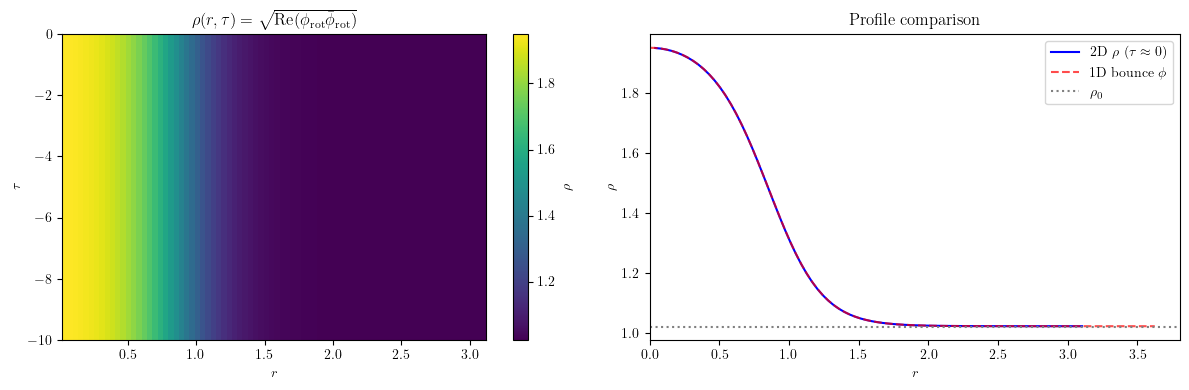

In [29]:
# Plot solution: rho = sqrt(Re(phi_rot * phibar_rot))
rho_2d = solver_diag.rho_map(y_f, ybar_f)
r_plot = np.asarray(solver_diag.grid.r, float)
tau_plot = np.asarray(solver_diag.grid.tau, float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 2D heatmap: rho(r, tau) — r on x-axis, tau on y-axis
im = axes[0].pcolormesh(r_plot, tau_plot, rho_2d.T, shading="auto", cmap="viridis")
axes[0].set_xlabel(r"$r$")
axes[0].set_ylabel(r"$\tau$")
axes[0].set_title(r"$\rho(r,\tau) = \sqrt{\mathrm{Re}(\phi_{\mathrm{rot}}\bar{\phi}_{\mathrm{rot}})}$")
plt.colorbar(im, ax=axes[0], label=r"$\rho$")

# 1D slice at tau=0 (or first slice) vs 1D bounce
rho_tau0 = rho_2d[:, 0]
axes[1].plot(r_plot, rho_tau0, "b-", label=r"2D $\rho$ ($\tau \approx 0$)")
axes[1].plot(r_1d, phi_1d, "r--", alpha=0.7, label=r"1D bounce $\phi$")
axes[1].axhline(rho0, color="gray", ls=":", label=r"$\rho_0$")
axes[1].set_xlabel(r"$r$")
axes[1].set_ylabel(r"$\rho$")
axes[1].set_title("Profile comparison")
axes[1].legend()
axes[1].set_xlim(0, None)

plt.tight_layout()
plt.show()

In [30]:
# ============================================================================
# PART 2 — Local ODE residual comparison + bulk vs boundary decomposition
# ============================================================================
from Bubble_finder.diagnostics_sanity import (
    local_ode_residual_comparison,
    bulk_vs_boundary_residual,
    bulk_vs_boundary_with_bc_compare,
)
from Bubble_finder.potential_bubble import dOmega_dphi

# (2a) Local ODE residual: 1D equation vs 2D reduced equation
loc = local_ode_residual_comparison(
    r_1d, phi_1d, solver_diag, dU, dOmega_dphi, float(PHI0), float(V1), float(V2),
)
print("PART 2a — Local ODE residual (excludes r=0):")
print(f"  Residual_1D_equation:     max = {loc['res_1d_max']:.6e}, mean = {loc['res_1d_mean']:.6e}")
print(f"  Residual_2D_reduced_eq:   max = {loc['res_2d_max']:.6e}, mean = {loc['res_2d_mean']:.6e}")
print(f"  n_pts = {loc['n_pts']}")
if loc['res_1d_max'] < 1e-6 and loc['res_2d_max'] > 0.01:
    print("  --> 1D solution satisfies 1D ODE but NOT 2D reduced eq → EQUATIONS DIFFER.")
elif loc['res_1d_max'] < 1e-6 and loc['res_2d_max'] < 1e-6:
    print("  --> Both residuals small → bulk equations match.")
print()

# (2b) Bulk vs boundary decomposition for embedded 1D config
dec = bulk_vs_boundary_residual(solver_diag, x_seed_embed)
print("PART 2b — Bulk vs boundary residual decomposition (tau_bc=twisted):")
print(f"  max_bulk (excl i=0, i=Nt-1)  = {dec['max_bulk']:.6e}")
print(f"  max_boundary (i=0 or i=Nt-1) = {dec['max_boundary']:.6e}")
print(f"  max at i=0                   = {dec['max_i0']:.6e}")
print(f"  max at i=Nt-1                = {dec['max_iNt1']:.6e}")
if dec['max_boundary'] > 10 * dec['max_bulk'] and dec['max_bulk'] < 0.01:
    print("  --> Bulk matches but BC is inconsistent (boundary residual dominates).")
print()

# (2c) Compare twisted vs neumann BC (requires allow_debug_bcs)
bc_compare = bulk_vs_boundary_with_bc_compare(solver_diag, x_seed_embed, U, dU, d2U)
if "error" in bc_compare:
    print("PART 2c — BC comparison: allow_debug_bcs=False, skipping tau_bc=neumann comparison.")
else:
    print("PART 2c — twisted vs neumann tau_bc:")
    print(f"  twisted:  max_bulk={bc_compare['max_bulk_twisted']:.6e}, max_boundary={bc_compare['max_boundary_twisted']:.6e}")
    print(f"  neumann:  max_bulk={bc_compare['max_bulk_neumann']:.6e}, max_boundary={bc_compare['max_boundary_neumann']:.6e}")

PART 2a — Local ODE residual (excludes r=0):
  Residual_1D_equation:     max = 5.077886e-04, mean = 6.463683e-05
  Residual_2D_reduced_eq:   max = 5.077886e-04, mean = 6.463683e-05
  n_pts = 997

PART 2b — Bulk vs boundary residual decomposition (tau_bc=twisted):
  max_bulk (excl i=0, i=Nt-1)  = 1.609316e-02
  max_boundary (i=0 or i=Nt-1) = 1.609316e-02
  max at i=0                   = 1.609316e-02
  max at i=Nt-1                = 1.609316e-02

PART 2c — BC comparison: allow_debug_bcs=False, skipping tau_bc=neumann comparison.


In [31]:
# ============================================================================
# PART 3 — Potential convention audit table
# ============================================================================
from Bubble_finder.diagnostics_sanity import potential_convention_audit
from Bubble_finder.potential_bubble import V_phi, dV_dphi

omega_audit = float(solver_diag.omega)
rho_hom = float(solver_diag.rho0)
rho_vals = np.unique(np.concatenate([
    [rho_hom], np.linspace(phi_1d.min(), phi_1d.max(), 5), [float(V1), float(V2)],
]))
audit = potential_convention_audit(rho_vals, V_phi, dV_dphi, float(PHI0), float(V1), float(V2),
                                   omega_audit, dU)
print("PART 3 — Potential convention audit table")
print("=" * 100)
print(f"{'rho':>8} {'V':>10} {'dV/dφ':>10} {'W_2d':>10} {'force_1d':>12} {'force_2d':>12} {'rel_diff':>10}")
print("-" * 100)
for row in audit["rows"]:
    rel = abs(row["force_1d"] - row["force_2d_reduced"]) / (abs(row["force_1d"]) + 1e-20)
    print(f"{row['rho']:8.4f} {row['V']:10.4f} {row['dV_dvarphi']:10.4f} {row['W_2d']:10.4f} "
          f"{row['force_1d']:12.4f} {row['force_2d_reduced']:12.4f} {rel:10.2e}")
print("=" * 100)
max_rel = max(abs(row["force_1d"] - row["force_2d_reduced"]) / (abs(row["force_1d"]) + 1e-20) for row in audit["rows"])
audit_ok = max_rel < 1e-6
print(f"  Potential audit: max_rel_diff = {max_rel:.2e}  {'PASS' if audit_ok else 'FAIL (expected < 1e-6 after factor-2 fix)'}")

PART 3 — Potential convention audit table
     rho          V      dV/dφ       W_2d     force_1d     force_2d   rel_diff
----------------------------------------------------------------------------------------------------
  1.0000    -0.5000     0.0000     0.0000      -0.7200      -0.7200   0.00e+00
  1.0198    -0.4930     0.6494     0.3184      -0.0848      -0.0848   0.00e+00
  1.0231    -0.4907     0.7367     0.3600       0.0000       0.0000   0.00e+00
  1.2550    -0.0859     1.4508     0.5780       0.5472       0.5472   0.00e+00
  1.4870    -0.1118    -1.8173    -0.6111      -2.8879      -2.8879   0.00e+00
  1.7189    -0.8199    -3.7286    -1.0846      -4.9662      -4.9662   0.00e+00
  1.9508    -1.4757    -1.0395    -0.2664      -2.4440      -2.4440   0.00e+00
  2.0000    -1.5000     0.0000     0.0000      -1.4400      -1.4400   0.00e+00
  Potential audit: max_rel_diff = 0.00e+00  PASS


In [32]:
# ============================================================================
# PART 4 — Charge definition report and corrected comparison
# ============================================================================
from Bubble_finder.diagnostics_sanity import charge_definition_report
from Bubble_finder.observables_2d import (
    compute_charge_tau0_ghost_2d,
    compute_charge_like_2d_from_1d,
)

charge_rep = charge_definition_report()
print("PART 4 — Charge definition report")
print("=" * 70)
for name, d in [("compute_charge_1d", charge_rep["compute_charge_1d"]),
                ("compute_charge_tau0_ghost_2d", charge_rep["compute_charge_tau0_ghost_2d"])]:
    print(f"  {name}:")
    for k, v in d.items():
        print(f"    {k}: {v}")
print("  Comparison: " + charge_rep["comparison_note"])
print("=" * 70)

# Apples-to-apples: 1D charge using 2D definition (same formula, same r grid)
compare_excess_Q = True  # Match notebook target
r_2d = np.asarray(solver_diag.grid.r, float)
Q_2d_total = compute_charge_tau0_ghost_2d(solver_diag, y_f, ybar_f, subtract_background=False)
Q_2d_excess = compute_charge_tau0_ghost_2d(solver_diag, y_f, ybar_f, subtract_background=True)
Q_1d_like_2d_total = compute_charge_like_2d_from_1d(r_1d, phi_1d, r_2d, omega_ref, rho0, subtract_background=False)
Q_1d_like_2d_excess = compute_charge_like_2d_from_1d(r_1d, phi_1d, r_2d, omega_ref, rho0, subtract_background=True)
print("\nCharge comparison (2D definition, same omega, same r grid):")
print(f"  Q_2d_total         = {Q_2d_total:.6e}")
print(f"  Q_2d_excess        = {Q_2d_excess:.6e}")
print(f"  Q_1d_like_2d_total  = {Q_1d_like_2d_total:.6e}")
print(f"  Q_1d_like_2d_excess = {Q_1d_like_2d_excess:.6e}")
if compare_excess_Q:
    diff = abs(Q_2d_excess - Q_1d_like_2d_excess)
    rel_diff = diff / (abs(Q_2d_excess) + 1e-30)
    print(f"  |Q_2d_excess - Q_1d_like_2d_excess| = {diff:.6e} (rel {rel_diff:.2e})")
else:
    diff = abs(Q_2d_total - Q_1d_like_2d_total)
    rel_diff = diff / (abs(Q_2d_total) + 1e-30)
    print(f"  |Q_2d_total - Q_1d_like_2d_total| = {diff:.6e} (rel {rel_diff:.2e})")

PART 4 — Charge definition report
  compute_charge_1d:
    formula: Q = 4*pi * omega * integral(r^2 * phi^2, dr)
    field: phi (unrotated amplitude)
    omega: passed as argument (must match 1D bounce omega)
    background_subtraction: False
    volume: full integration from r[0] to r[-1]
  compute_charge_tau0_ghost_2d:
    formula: Q = 4*pi * integral(r^2 * q, dr), q = (1/2)*Re(phibar*phi_tau - phi*phibar_tau)
    field: phi, phibar (unrotated), reconstructed at tau=0 via ghost
    omega: solver.omega
    background_subtraction: optional subtract_background=True => Q -= Q_homogeneous_ball(omega, rho0, r_max)
    volume: r from grid
  Comparison: For apples-to-apples: use same omega, compare EXCESS charge (subtract background) for both.

Charge comparison (2D definition, same omega, same r grid):
  Q_2d_total         = 8.385877e+01
  Q_2d_excess        = 5.768892e+00
  Q_1d_like_2d_total  = 8.386517e+01
  Q_1d_like_2d_excess = 5.775300e+00
  |Q_2d_excess - Q_1d_like_2d_excess| = 6.408

In [33]:
# ============================================================================
# REGRESSION CHECK — After factor-2 fix: bulk and boundary comparable, equations match
# ============================================================================
# With the fix: (i) local 1D and 2D ODE residuals agree, (ii) bulk ~ boundary (no BC spike).
# Discretization/interpolation limit how small the residual can be; we check bulk ~ boundary.
dec_reg = bulk_vs_boundary_residual(solver_diag, x_seed_embed)
ratio = dec_reg["max_boundary"] / (dec_reg["max_bulk"] + 1e-30)
# Before fix: boundary >> bulk (tau BC mismatch). After fix: ratio ~ 1.
bulk_bound_ok = ratio < 2.0 and dec_reg["max_bulk"] < 100.0  # no boundary spike, reasonable scale
print("REGRESSION CHECK (embedded 1D @ eta0=0, after factor-2 fix):")
print(f"  max_bulk     = {dec_reg['max_bulk']:.6e}")
print(f"  max_boundary = {dec_reg['max_boundary']:.6e}")
print(f"  ratio (boundary/bulk) = {ratio:.4f}  (should be ~1 if BC consistent)")
if bulk_bound_ok:
    print("  --> PASS: bulk and boundary comparable (no tau-BC spike)")
else:
    print("  --> Check: if ratio >> 1, tau BC may be inconsistent")

REGRESSION CHECK (embedded 1D @ eta0=0, after factor-2 fix):
  max_bulk     = 1.609316e-02
  max_boundary = 1.609316e-02
  ratio (boundary/bulk) = 1.0000  (should be ~1 if BC consistent)
  --> PASS: bulk and boundary comparable (no tau-BC spike)


## Third try: continuation in eta0 from the static bubble (twisted BC)

We build the static tau-independent bubble at eta0=0, then perform continuation in eta0 to trace how the solution develops tau-dependence under twisted boundary conditions.

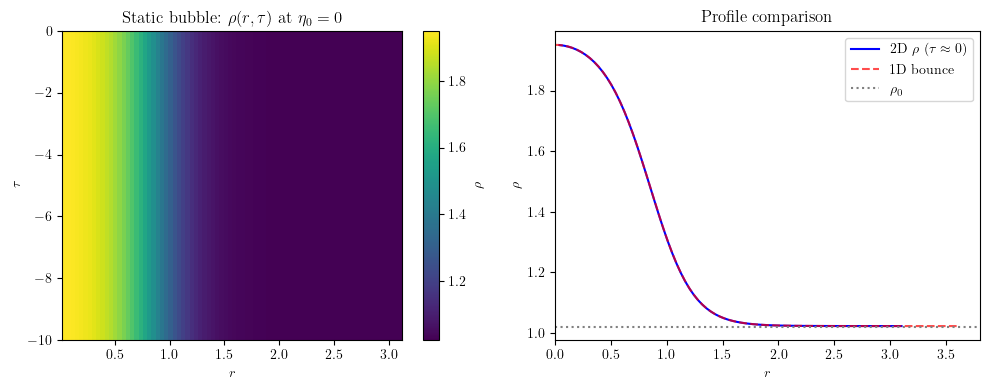

In [34]:
# ============================================================================
# B.1 — Static solution at eta0=0 (already converged in Second try)
# ============================================================================
# Reuse solver_diag, result_embed, x_seed_embed from TASK B.
# Ensure we have a converged static bubble for continuation.
x_static_eta0 = result_embed.x if result_embed is not None and result_embed.success else x_seed_embed
y_static, ybar_static = solver_diag.unpack(x_static_eta0)
phi_rot_static, _ = solver_diag.phi_rot(y_static, ybar_static)
rho_static = solver_diag.rho_map(y_static, ybar_static)
r_plot = np.asarray(solver_diag.grid.r, float)
tau_plot = np.asarray(solver_diag.grid.tau, float)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im = axes[0].pcolormesh(r_plot, tau_plot, rho_static.T, shading="auto", cmap="viridis")
axes[0].set_xlabel(r"$r$")
axes[0].set_ylabel(r"$\tau$")
axes[0].set_title(r"Static bubble: $\rho(r,\tau)$ at $\eta_0=0$")
plt.colorbar(im, ax=axes[0], label=r"$\rho$")
axes[1].plot(r_plot, rho_static[:, 0], "b-", label=r"2D $\rho$ ($\tau \approx 0$)")
axes[1].plot(r_1d, phi_1d, "r--", alpha=0.7, label="1D bounce")
axes[1].axhline(rho0, color="gray", ls=":", label=r"$\rho_0$")
axes[1].set_xlabel(r"$r$")
axes[1].set_ylabel(r"$\rho$")
axes[1].set_title("Profile comparison")
axes[1].legend()
axes[1].set_xlim(0, None)
plt.tight_layout()
plt.show()

In [42]:
# ============================================================================
# B.2 — Continuation scan in eta0 from 0 to eta_max
# ============================================================================
from Bubble_finder.observables_2d import compute_charge_tau0_ghost_2d
from Bubble_finder.bounce2d import NewtonConvergenceError
from dataclasses import replace

# Parameters for continuation
eta_max = 5e-0
n_eta_steps = 50
eta_grid = np.linspace(0.0, eta_max, n_eta_steps)
eps_tau_bump = 1e-5  # Small tau-dependent perturbation if solver stays tau-independent (documented)
use_tau_bump_from_step = 1  # Add bump starting at first nonzero eta (k=1) if needed

# Create a fresh solver for continuation (same grid, but eta0 will change each step)
solver_cont = Bubble2DSolver(
    replace(solver_diag.settings, eta0=0.0),
    U, dU, d2U
)
solver_cont.omega = float(getattr(solver_diag, "omega", OMEGA))
solver_cont.rho0 = float(solver_diag.rho0)

# Optional: seed_tau_bump for tau-dependence kick (localized near tau=0, small r)
Nr, Nt = solver_cont.Nr, solver_cont.Nt
r_arr = np.asarray(solver_cont.grid.r, float)
tau_arr = np.asarray(solver_cont.grid.tau, float)
if r_arr.ndim == 1:
    r_arr = r_arr[:, None]
sigma_r, sigma_tau = 2.0, 0.1 * abs(tau_arr[-1] - tau_arr[0])
r_c, tau_c = float(np.median(r_arr)), float(tau_arr[0])
bump_profile = np.exp(-((r_arr - r_c)**2) / (2*sigma_r**2)) * np.exp(-((tau_arr - tau_c)**2) / (2*sigma_tau**2))
bump_y = np.broadcast_to(r_arr * bump_profile, (Nr, Nt))
bump_ybar = -0.5 * bump_y.copy()
seed_tau_bump = (bump_y, bump_ybar)

records = []
x_prev = np.array(x_static_eta0, copy=True)

for k, eta_k in enumerate(eta_grid):
    solver_cont.eta0 = float(eta_k)
    solver_cont.settings = replace(solver_cont.settings, eta0=float(eta_k))
    x0 = np.array(x_prev, copy=True)
    # Add small tau-dependent perturbation from step use_tau_bump_from_step to help tau-dependence turn on
    if k >= use_tau_bump_from_step and eta_k > 0:
        from Bubble_finder.ansatz_bubble import build_twisted_seed_from_static
        x_bump = build_twisted_seed_from_static(
            solver=solver_cont, r_1d=r_1d, phi_1d=phi_1d, rho0=rho0,
            a=1.0, seed_tau_bump=seed_tau_bump
        )
        x0 = x_prev + eps_tau_bump * (x_bump - x_static_eta0)
    success = False
    niter = 0
    res_final = np.nan
    try:
        res = solver_cont.solve(x0, verbose=False, store_iteration_history=False)
        success = res.success
        niter = res.iterations
        res_final = res.residual_norm
        x_prev = res.x
    except (NewtonConvergenceError, Exception) as e:
        pass
    y_k, ybar_k = solver_cont.unpack(x_prev)
    phi_rot_k, _ = solver_cont.phi_rot(y_k, ybar_k)
    Q_k = compute_charge_tau0_ghost_2d(solver_cont, y_k, ybar_k, subtract_background=False)
    tau_std_k = float(np.max(np.std(np.real(phi_rot_k), axis=1)))
    records.append(dict(eta=eta_k, success=success, niter=niter, res=res_final, Q=Q_k, tau_std=tau_std_k))
    print(f"  eta={eta_k:.2e}  ok={success}  it={niter}  ||F||={res_final:.2e}  Q={Q_k:.4e}  tau_std={tau_std_k:.2e}")

# Compact table
print("\\nContinuation table:")
print(f"{'eta0':>10} {'ok':>5} {'iter':>5} {'||F||':>12} {'Q':>12} {'tau_std':>12}")
for r in records:
    print(f"{r['eta']:>10.2e} {str(r['success']):>5} {r['niter']:>5} {r['res']:>12.2e} {r['Q']:>12.4e} {r['tau_std']:>12.2e}")


Newton converged — diagnostica risultati
  Convergenza: success, iterazioni = 1
  Residuo finale ||F|| = 7.723447e-09
  Carica Q(τ[0])      = +8.385877e+01  (primo slice, tau=-Δτ/2)
  Energia E(τ=0) slice = 5.976480e+01  (su griglia τ[0])
  Energia E(τ=0) ghost = 5.976480e+01  (ricostruita a τ=0 come Q-ball)
  Sanity (η0=0): ||F||=1.940e+01, ω²−W(ρ0)=4.159e-02

  eta=0.00e+00  ok=True  it=1  ||F||=7.72e-09  Q=8.3859e+01  tau_std=8.06e-16

Newton converged — diagnostica risultati
  Convergenza: success, iterazioni = 5
  Residuo finale ||F|| = 2.208316e-12
  Carica Q(τ[0])      = +8.454995e+01  (primo slice, tau=-Δτ/2)
  Energia E(τ=0) slice = 6.055777e+01  (su griglia τ[0])
  Energia E(τ=0) ghost = 6.055778e+01  (ricostruita a τ=0 come Q-ball)
  Sanity (η0=0): ||F||=1.940e+01, ω²−W(ρ0)=4.159e-02

  eta=1.02e-01  ok=True  it=5  ||F||=2.21e-12  Q=8.4550e+01  tau_std=2.80e-02

Newton converged — diagnostica risultati
  Convergenza: success, iterazioni = 5
  Residuo finale ||F|| = 2.572666

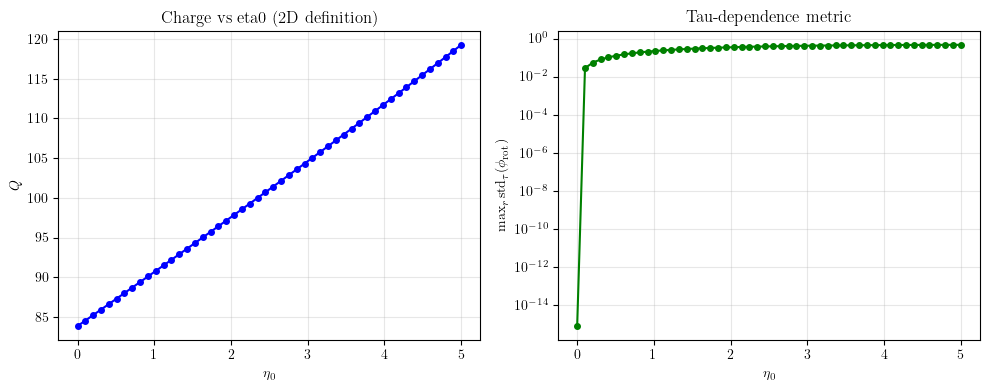

In [43]:
# ============================================================================
# B.4 — Plots: Q(eta), tau-dependence metric vs eta
# ============================================================================
eta_vals = np.array([r["eta"] for r in records])
Q_vals = np.array([r["Q"] for r in records])
tau_std_vals = np.array([r["tau_std"] for r in records])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(eta_vals, Q_vals, "bo-", markersize=4)
axes[0].set_xlabel(r"$\eta_0$")
axes[0].set_ylabel(r"$Q$")
axes[0].set_title("Charge vs eta0 (2D definition)")
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(eta_vals, tau_std_vals + 1e-20, "go-", markersize=4)
axes[1].set_xlabel(r"$\eta_0$")
axes[1].set_ylabel(r"$\max_r \mathrm{std}_\tau(\phi_{\mathrm{rot}})$")
axes[1].set_title("Tau-dependence metric")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

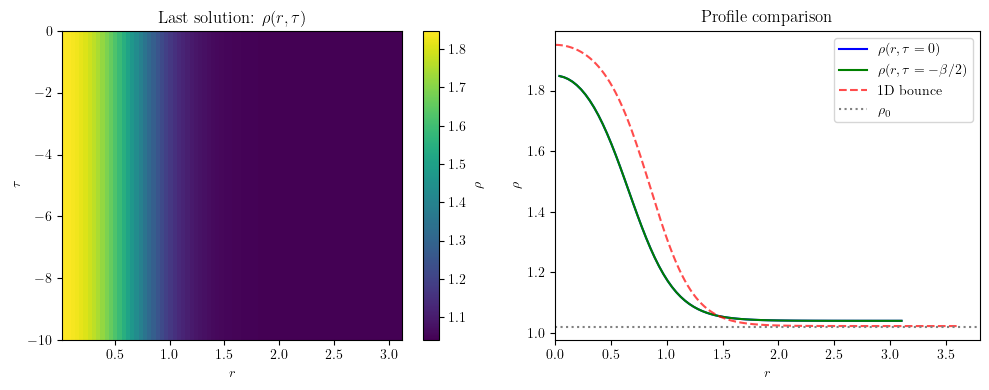

In [44]:
# Last solution: rho 2D and slices at tau=0, tau=-beta/2 vs 1D bounce
y_last, ybar_last = solver_cont.unpack(x_prev)
rho_last = solver_cont.rho_map(y_last, ybar_last)
r_plot = np.asarray(solver_cont.grid.r, float)
tau_plot = np.asarray(solver_cont.grid.tau, float)
beta = float(solver_cont.settings.beta)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im = axes[0].pcolormesh(r_plot, tau_plot, rho_last.T, shading="auto", cmap="viridis")
axes[0].set_xlabel(r"$r$")
axes[0].set_ylabel(r"$\tau$")
axes[0].set_title(r"Last solution: $\rho(r,\tau)$")
plt.colorbar(im, ax=axes[0], label=r"$\rho$")

# Slices at tau=0 (index 0) and tau=-beta/2 (index -1), plus 1D bounce
axes[1].plot(r_plot, rho_last[:, 0], "b-", label=r"$\rho(r, \tau=0)$")
axes[1].plot(r_plot, rho_last[:, -1], "g-", label=r"$\rho(r, \tau=-\beta/2)$")
axes[1].plot(r_1d, phi_1d, "r--", alpha=0.7, label="1D bounce")
axes[1].axhline(rho0, color="gray", ls=":", label=r"$\rho_0$")
axes[1].set_xlabel(r"$r$")
axes[1].set_ylabel(r"$\rho$")
axes[1].set_title("Profile comparison")
axes[1].legend()
axes[1].set_xlim(0, None)
plt.tight_layout()
plt.show()

## 5. Best ansatz selection on a small parameter grid (non-oscillatory)

We use the **gated bubble** family only (build_seed_bubble with eps=0, no oscillatory kick) with twisted BC. We scan a small parameter grid over amp and tau_gate_frac, rank by residual norm, run Newton, and plot the converged solution.


In [24]:
# ============================================================================
# Section 5: Non-oscillatory seed selection, Newton solve, and plots
# ============================================================================
# Uses solver_diag, r_1d, phi_1d, rho0 from Second try diagnostics. Twisted BC only.

from Bubble_finder.ansatz_bubble import (
    AnsatzParams, build_seed_bubble,
    make_q_ball_objects, make_bubble_profile_1d_from_arrays,
)
from Bubble_finder.observables_2d import compute_charge_tau0_ghost_2d
from Bubble_finder.bounce2d import NewtonConvergenceError

def evaluate_seed(solver, x0, name="", extra_meta=None):
    """Compute residual norms, tau_std_rho, boundary flag. rho from phi_rot*phibar_rot."""
    F = np.asarray(solver.residual(x0), dtype=float)
    n_sites = F.size
    nF_inf = float(np.max(np.abs(F)))
    nF_2 = float(np.linalg.norm(F))
    nF_2_per_site = nF_2 / np.sqrt(n_sites) if n_sites > 0 else 0.0
    flat_idx = int(np.argmax(np.abs(F)))
    j_max = flat_idx // solver.Nt if solver.Nt > 0 else 0
    i_max = flat_idx % solver.Nt if solver.Nt > 0 else 0
    at_boundary = (j_max == 0 or j_max == solver.Nr - 1 or i_max == 0 or i_max == solver.Nt - 1)
    y, ybar = solver.unpack(x0)
    phi_rot, phibar_rot = solver.phi_rot(y, ybar)
    u = np.maximum((phi_rot * phibar_rot).real, 0.0)
    rho = np.sqrt(u)
    tau_std_rho = float(np.max(np.std(rho, axis=1))) if rho.size > 0 else 0.0
    return dict(
        name=name, nF_inf=nF_inf, nF_2_per_site=nF_2_per_site,
        tau_std_rho=tau_std_rho, at_boundary=at_boundary,
        j_max=j_max, i_max=i_max, extra=extra_meta or {},
    )

# Solver: use diagnostic solver if available (run "Second try: diagnostics" first),
# else fall back to section 4 solver (run section 4 first)
try:
    solver_s5 = solver_diag
    r_1d = r_1d
    phi_1d = phi_1d
except NameError:
    solver_s5 = solver_s4
    r_1d = r_1d_s4
    phi_1d = phi_1d_s4
rho0_s5 = float(solver_s5.rho0)
grid2d, fields, potential, _, _ = make_q_ball_objects(solver_s5)
omega_ref = float(getattr(solver_s5, "omega", OMEGA))
eta0_s5 = float(getattr(solver_s5, "eta0", 0.0))
bubble_profile_1d = make_bubble_profile_1d_from_arrays(r_1d, phi_1d)

# Candidate seeds: gated_bubble only (eps=0, no oscillatory kick)
candidates = []
neg_mode_dummy = (np.zeros_like(fields.grid.r), np.zeros_like(fields.grid.r), 0.0)
for amp in [1.0]:
    for tau_gate_frac in [0.12, 0.18, 0.22, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]:
        params = AnsatzParams(eps=0.0, k=1, phase=0.0, amp=amp, tau_gate_frac=tau_gate_frac, r_window_frac=0.15)
        try:
            x0_g, _ = build_seed_bubble(
                grid=grid2d, fields=fields, potential=potential,
                omega_ref=omega_ref, omega_tilde=omega_ref,
                bubble_profile_1d=bubble_profile_1d, params=params,
                neg_mode_override=neg_mode_dummy,
            )
            rep = evaluate_seed(solver_s5, x0_g, "gated_bubble", {"amp": amp, "tau_gate_frac": tau_gate_frac})
            rep["x0"] = x0_g
            candidates.append(rep)
        except Exception as e:
            pass

# Sort by nF_inf (best first)
candidates.sort(key=lambda c: c["nF_inf"])
best = candidates[0]
best_x0 = best["x0"]
best_name = best["name"]
best_params = best.get("extra", {})

print("Seed ranking table (by ||F||_inf):")
print(f"{'name':<22} {'params':<20} {'||F||_inf':>12} {'||F||_2/sqrt(N)':>14} {'tau_std_rho':>12} {'boundary':>8}")
for c in candidates:
    params_str = str(c.get("extra", {}))[:18]
    print(f"{c['name']:<22} {params_str:<20} {c['nF_inf']:>12.4e} {c['nF_2_per_site']:>14.4e} {c['tau_std_rho']:>12.4e} {str(c['at_boundary']):>8}")

print(f"\nBest seed: {best_name} {best_params}")

# Newton solve
result_s5 = None
try:
    result_s5 = solver_s5.solve(best_x0, verbose=True, store_iteration_history=False)
    print(f"\nNewton: success={result_s5.success}, iters={result_s5.iterations}, final ||F||={result_s5.residual_norm:.4e}")
except (NewtonConvergenceError, Exception) as e:
    print(f"\nNewton failed: {e}")
    if len(candidates) > 1:
        print("Trying fallback (second-best seed)...")
        best_x0 = candidates[1]["x0"]
        try:
            result_s5 = solver_s5.solve(best_x0, verbose=True, store_iteration_history=False)
        except Exception as e2:
            print(f"Fallback also failed: {e2}")

# Use converged solution or best seed for plotting
x_final = result_s5.x if result_s5 is not None and result_s5.success else best_x0
y_fin, ybar_fin = solver_s5.unpack(x_final)
rho_fin = solver_s5.rho_map(y_fin, ybar_fin)
Q_s5 = compute_charge_tau0_ghost_2d(solver_s5, y_fin, ybar_fin, subtract_background=False)
phi_rot_fin, _ = solver_s5.phi_rot(y_fin, ybar_fin)
tau_std_fin = float(np.max(np.std(np.real(phi_rot_fin), axis=1)))
print(f"\nFinal: Q (2D) = {Q_s5:.6e}, tau_std_rho = {tau_std_fin:.6e}")

# Compatibility with downstream cells (section 6+)
best_seed = type("_BestSeed", (), {})()
best_seed.best_x0 = best_x0
best_seed.best_score = best["nF_inf"]
best_seed.best_norm = best["nF_inf"]
best_seed.best_params = {**best_params, "omega_tilde": omega_ref}
best_seed.best_Q = Q_s5
best_seed.best_Q_excess = Q_s5 - (Q_hom if "Q_hom" in dir() else 0)
best_seed.best_meta = best.get("extra", {})
best_grid = grid2d
best_candidate = type("_BestCandidate", (), {})()
best_candidate.omega_tilde = omega_ref
best_candidate.meta = {"rho_ref": rho0_s5}
BETA_USED = float(solver_s5.settings.beta)


Seed ranking table (by ||F||_inf):
name                   params                  ||F||_inf ||F||_2/sqrt(N)  tau_std_rho boundary
gated_bubble           {'amp': 1.0, 'tau_     2.0683e+00     2.7180e-01   2.7936e-01    False
gated_bubble           {'amp': 1.0, 'tau_     2.0769e+00     2.6272e-01   3.0618e-01    False
gated_bubble           {'amp': 1.0, 'tau_     2.0868e+00     2.5247e-01   3.3286e-01    False
gated_bubble           {'amp': 1.0, 'tau_     2.0994e+00     2.4210e-01   3.5674e-01    False
gated_bubble           {'amp': 1.0, 'tau_     2.1148e+00     2.3129e-01   3.7763e-01    False
gated_bubble           {'amp': 1.0, 'tau_     2.1336e+00     2.1999e-01   3.9601e-01    False
gated_bubble           {'amp': 1.0, 'tau_     2.1575e+00     2.0826e-01   4.1221e-01    False
gated_bubble           {'amp': 1.0, 'tau_     2.1886e+00     1.9640e-01   4.2648e-01    False
gated_bubble           {'amp': 1.0, 'tau_     2.2150e+00     1.8964e-01   4.3420e-01    False
gated_bubble           {

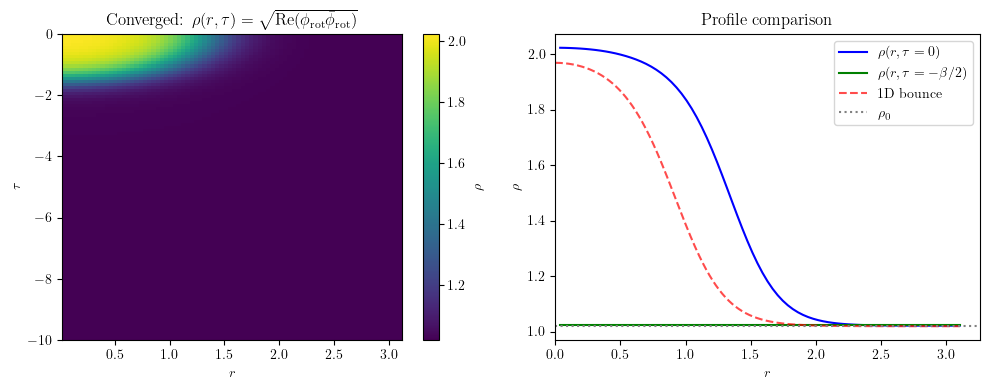

In [26]:
# Plot converged solution: rho 2D heatmap + slices at tau=0, tau=-beta/2 vs 1D bounce
r_plot = np.asarray(solver_s5.grid.r, float)
tau_plot = np.asarray(solver_s5.grid.tau, float)
beta = float(solver_s5.settings.beta)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im = axes[0].pcolormesh(r_plot, tau_plot, rho_fin.T, shading="auto", cmap="viridis")
axes[0].set_xlabel(r"$r$")
axes[0].set_ylabel(r"$\tau$")
axes[0].set_title(r"Converged: $\rho(r,\tau) = \sqrt{\mathrm{Re}(\phi_{\mathrm{rot}}\bar{\phi}_{\mathrm{rot}})}$")
plt.colorbar(im, ax=axes[0], label=r"$\rho$")

axes[1].plot(r_plot, rho_fin[:, 0], "b-", label=r"$\rho(r, \tau=0)$")
axes[1].plot(r_plot, rho_fin[:, -1], "g-", label=r"$\rho(r, \tau=-\beta/2)$")
axes[1].plot(r_1d, phi_1d, "r--", alpha=0.7, label="1D bounce")
axes[1].axhline(rho0_s5, color="gray", ls=":", label=r"$\rho_0$")
axes[1].set_xlabel(r"$r$")
axes[1].set_ylabel(r"$\rho$")
axes[1].set_title("Profile comparison")
axes[1].legend()
axes[1].set_xlim(0, None)
plt.tight_layout()
plt.show()


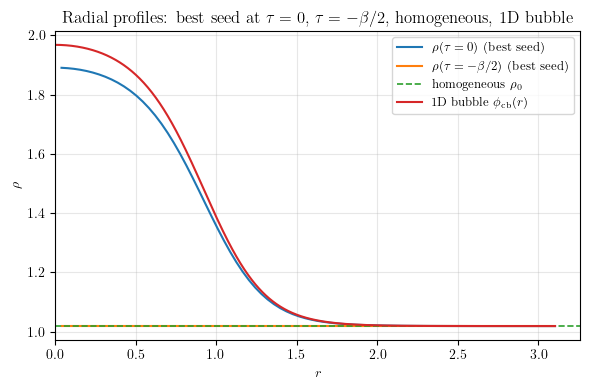

In [27]:
# rho(r) at tau=0, tau=-beta/2 for best seed (from section 5)
# Requires section 5: solver_s5, best_x0, best_grid
sol_plt = solver_s5
g_plt = best_grid if "best_grid" in dir() else sol_plt.grid
y_plt, ybar_plt = sol_plt.unpack(best_x0)
rho_seed = sol_plt.rho_map(y_plt, ybar_plt)  # (Nr, Nt)

r = np.asarray(g_plt.r, float)
rho_tau0 = rho_seed[:, 0]
rho_tau_mid = rho_seed[:, -1]
rho0_ref = float(sol_plt.rho0)
r_cb = r_1d if "r_1d" in dir() else globals().get("r_bounce")
phi_cb = phi_1d if "phi_1d" in dir() else globals().get("phi_bounce")

fig_rho, ax_rho = plt.subplots(1, 1, figsize=(6, 4))
ax_rho.plot(r, rho_tau0, "C0-", lw=1.5, label=r"$\rho(\tau=0)$ (best seed)")
ax_rho.plot(r, rho_tau_mid, "C1-", lw=1.5, label=r"$\rho(\tau=-\beta/2)$ (best seed)")
ax_rho.axhline(rho0_ref, color="C2", ls="--", lw=1.2, label=r"homogeneous $\rho_0$")
if r_cb is not None and phi_cb is not None:
    ax_rho.plot(r_cb, phi_cb, "C3-", lw=1.5, label=r"1D bubble $\phi_{\mathrm{cb}}(r)$")
ax_rho.set_xlabel(r"$r$")
ax_rho.set_ylabel(r"$\rho$")
ax_rho.set_title(r"Radial profiles: best seed at $\tau=0$, $\tau=-\beta/2$, homogeneous, 1D bubble")
ax_rho.legend(loc="best", fontsize=9)
ax_rho.set_xlim(0, None)
ax_rho.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

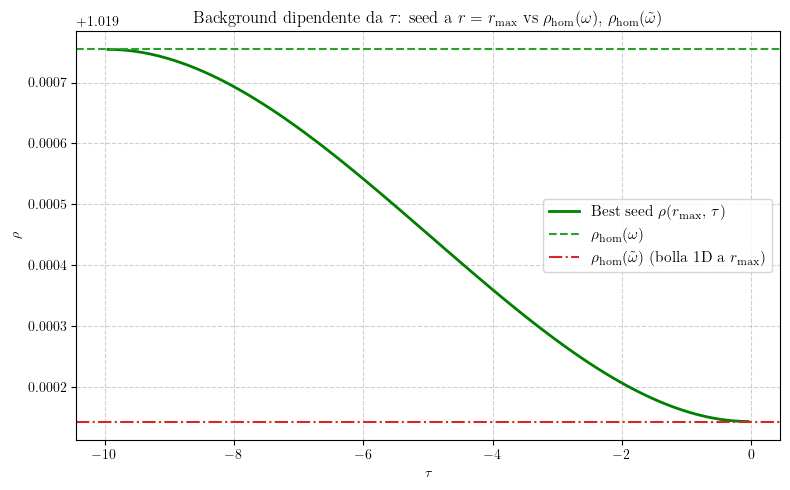

In [28]:
# ρ(r=r_max, τ) vs τ for best seed (from section 5)
# Requires section 5: solver_s5, best_x0, best_grid; rho_seed from previous cell if run, else recompute
g_plt = best_grid if "best_grid" in dir() else solver_s5.grid
if "rho_seed" not in dir():
    y_plt, ybar_plt = solver_s5.unpack(best_x0)
    rho_seed = solver_s5.rho_map(y_plt, ybar_plt)
r_max = float(g_plt.r[-1])
rho_seed_at_rmax = rho_seed[-1, :]
rho_hom = float(solver_s5.rho0)
phi_cb_arr = phi_1d if "phi_1d" in dir() and phi_1d is not None else globals().get("phi_bounce")
rho_tilde_at_rmax = float(phi_cb_arr[-1]) if phi_cb_arr is not None and len(phi_cb_arr) > 0 else None

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(g_plt.tau, rho_seed_at_rmax, "g-", lw=2, label=r"Best seed $\rho(r_{\max},\, \tau)$")
ax.axhline(rho_hom, color="C2", ls="--", lw=1.5, label=r"$\rho_{\mathrm{hom}}(\omega)$")
if rho_tilde_at_rmax is not None:
    ax.axhline(rho_tilde_at_rmax, color="C3", ls="-.", lw=1.5,
               label=r"$\rho_{\mathrm{hom}}(\tilde\omega)$ (bolla 1D a $r_{\max}$)")
ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$\rho$")
ax.set_title(r"Background dipendente da $\tau$: seed a $r=r_{\max}$ vs $\rho_{\mathrm{hom}}(\omega)$, $\rho_{\mathrm{hom}}(\tilde\omega)$")
ax.legend(fontsize=11)
ax.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

## 5.5. Solver diagnostics: sanity test and Jacobian consistency

Before running Newton's method, we verify that the solver is correctly configured:

1. **Sanity test**: Check that `y=ybar=0` (homogeneous background) gives `||F|| ≈ 0`.
   This requires that `phi_false` (or `rho0`) is a true homogeneous solution for the chosen `omega`,
   i.e., `W(phi_false²) = ω²` or equivalently `V'(ρ₀) = 2ω²ρ₀`.

2. **Jacobian consistency**: Verify that the analytical Jacobian matches finite-difference approximation
   by testing `J @ v ≈ (F(x + εv) - F(x)) / ε` for random directions `v`.

If the sanity test fails, adjust `(rho0, omega)` or solve for `omega` given `rho0` to ensure consistency.

In [23]:
# ============================================================================
# Solver diagnostics: sanity test and Jacobian consistency check
# ============================================================================

# Create a test solver with the best grid (same settings as will be used for Newton)
settings_test = Bubble2DSettings(
    Nr=best_grid.Nr,
    Ntau=best_grid.Nt,
    Lr=best_grid.dr * best_grid.Nr,
    beta=best_beta,
    omega_ref=OMEGA,
    rho0_bracket=(1.0, 1.1),
    newton_tol=1e-8,
    newton_max_iter=35,
    damping=1,
    newton_verbose=False,
    tau_bc="twisted",
)

solver_test = Bubble2DSolver(settings_test, U, dU, d2U)

# 1. Sanity tests: run_sanity_tests() returns dict(background_eta0_zero=..., twist_source=...)
print("=" * 70)
print("Sanity Test: Homogeneous Background (eta0=0)")
print("=" * 70)
sanity = solver_test.run_sanity_tests()
d0 = sanity["background_eta0_zero"]
ok_sanity = d0["residual_norm"] < 1e-6
msg_sanity = (
    f"||F||={d0['residual_norm']:.3e}. "
    f"Background: omega^2-W(ρ0)={d0['omega2_minus_W']:.3e} with ρ0={d0['rho0']:.3e}."
)
print(f"Result: {'PASS' if ok_sanity else 'FAIL'}")
print(f"Details: {msg_sanity}")
if not ok_sanity:
    print("\n⚠️  WARNING: Background may not solve the bulk PDE.")
    print("   Consider adjusting (rho0, omega) or solving for omega given rho0.")
print()

# 2. Jacobian consistency check: check_jacobian(x, n_tests, eps) -> dict(max_rel, mean_rel, all)
print("=" * 70)
print("Jacobian Consistency Check")
print("=" * 70)
# State vector is real (Re/Im split when complex_saddle=True); perturb in same format
x0 = np.asarray(best_seed.best_x0).ravel().astype(float)
x_test = x0 + 0.01 * np.random.randn(x0.size)
x_test = x_test / (np.linalg.norm(x_test) + 1e-30) * np.linalg.norm(x0)

jacobian_check = solver_test.check_jacobian(x_test, n_tests=3, eps=1e-7)
max_rel = jacobian_check["max_rel"]
mean_rel = jacobian_check["mean_rel"]
test_results = jacobian_check["all"]
print(f"Max relative error: {max_rel:.3e}")
print(f"Mean relative error: {mean_rel:.3e}")
print(f"Individual test errors: {[f'{e:.3e}' for e in test_results]}")
if max_rel < 1e-5:
    print("✓ Jacobian is consistent (error < 1e-5)")
else:
    print("⚠️  WARNING: Large Jacobian inconsistency detected.")
print("=" * 70)

NameError: name 'best_beta' is not defined

**Background consistency (1D vs 2D).** The 2D solver no longer overwrites `phi_false`: it uses the value you pass (e.g. `phi_false_bounce` from the 1D bounce) or `settings.rho0` if set. So when building the solver, pass `phi_false` equal to the 1D false vacuum (or set `settings.rho0`) so that 1D and 2D are consistent.

**Seed selection.** The functions `select_best_negative_mode_seed_bubble` and `select_best_anchored_seed_bubble` now take `phi_false_solver=solver.phi_false` and `omega_reference=solver.omega`, and they (1) shift the 1D profile so that at large $r$ it tends to `solver.phi_false`, and (2) enforce discrete boundary conditions (Dirichlet at $r_{\max}$ and at $\tau_{\mathrm{past}}$ when applicable, and $\bar y(\tau=0)=y(\tau=0)$ to avoid a kink at $\tau=0$). If you build a manual ansatz (e.g. with `build_anchored_negative_mode_ansatz_bubble`) instead of using the best-from-scan seed, call `_enforce_seed_bcs(ansatz, solver)` before packing into the solver vector.

## 6. Newton solve from the best ansatz

Finally we solve the full **2D bubble nucleation problem** using Newton's method, starting from the
best ansatz found in the parameter scan.

The Newton iteration updates the vector of fields $x = (y,y_\mathrm{b})$ according to
$$
J[x_n] \, \delta x_n = - F[x_n] \,, \qquad x_{n+1} = x_n + \delta x_n \, ,
$$
where $F$ is the residual of the discretized equations of motion and $J$ is the corresponding Jacobian.
We use a **damped** Newton method with backtracking line search to ensure convergence.

In this section we:

1. build a `Bubble2DSolver` on the selected grid and parameters,
2. run the Newton iterations with `verbose=True`,
3. store the density $\rho(r,\tau) = \sqrt{\phi\bar\phi}$ at each iteration for diagnostics,
4. plot **all intermediate iterations** and then the **final solution** separately to visualize the
   approach to the 2D bubble configuration.


In [29]:
# ============================================================================
# Newton solve from best ansatz (section 5 scan)
# ============================================================================
# Uses best seed from section 5: best_x0, best_grid, BETA_USED, omega_ref, rho0_s5

grid_newton = best_grid
beta_newton = BETA_USED
omega_tilde_newton = omega_ref
x0_newton = best_x0
rho0_newton = float(rho0_s5)

# Twist η: eta = T*(omega_tilde - omega_ref); eta0 is passed directly (no factor-of-2)
ETA0 = beta_newton * (omega_tilde_newton - OMEGA)

# Grid can be Grid2D (.Nt) from ansatz_bubble or RadialTimeGrid (.Ntau) from Q_ball_finder
_ntau = getattr(grid_newton, "Nt", getattr(grid_newton, "Ntau", len(grid_newton.tau)))
settings_newton = Bubble2DSettings(
    Nr=grid_newton.Nr,
    Ntau=_ntau,
    Lr=grid_newton.dr * grid_newton.Nr,
    beta=beta_newton,
    omega_ref=OMEGA,
    rho0=rho0_newton,
    rho0_bracket=(1.0, 1.15),
    newton_tol=1e-8,
    newton_max_iter=20,
    damping=0.1,
    newton_verbose=True,
    tau_bc="twisted", #twisted, hom_past, neumann
    eta0=ETA0,
    #allow_debug_bcs=True,
)

# Solver: same frame as seed (omega=OMEGA, rho0=rho_hom(OMEGA)) so the initial guess is consistent
solver_newton = Bubble2DSolver(settings_newton, U, dU, d2U)
# Keep omega and rho0 from settings (omega_ref=OMEGA → rho0=rho_hom(OMEGA)); do NOT use omega_tilde

# Initial condition: best seed from section 5 scan
print("Running Newton solve from best seed (section 5)...")
newton_result = solver_newton.solve(x0_newton, verbose=True, store_iteration_history=True)

print("=" * 70)
print("Newton solve summary")
print("=" * 70)
print(f"  Converged: {newton_result.success}")
print(f"  Iterations: {newton_result.iterations}")
print(f"  Final ||F|| = {newton_result.residual_norm:.6e}")

Running Newton solve from best seed (section 5)...
[Newton-bubble] iter=01, ||F||=4.862e+01, Q(τ[0])=+8.379153e+01, E(τ=0)=5.977916e+01
  max|F|=3.877e+00 at (r=0.892, tau=-2.550)
[Newton-bubble] iter=02, ||F||=4.534e+01, Q(τ[0])=+8.372193e+01, E(τ=0)=5.895601e+01
  max|F|=3.638e+00 at (r=0.892, tau=-2.350)
[Newton-bubble] iter=03, ||F||=2.816e+01, Q(τ[0])=+8.116593e+01, E(τ=0)=5.503523e+01
  max|F|=3.410e+00 at (r=0.388, tau=-1.850)
[Newton-bubble] iter=04, ||F||=2.779e+01, Q(τ[0])=+8.114514e+01, E(τ=0)=5.563642e+01
  max|F|=3.430e+00 at (r=0.388, tau=-1.850)
[Newton-bubble] iter=05, ||F||=2.616e+01, Q(τ[0])=+8.105098e+01, E(τ=0)=5.697248e+01
  max|F|=3.533e+00 at (r=0.465, tau=-1.850)
[Newton-bubble] iter=06, ||F||=2.269e+01, Q(τ[0])=+8.092131e+01, E(τ=0)=5.836124e+01
  max|F|=3.016e+00 at (r=0.465, tau=-1.850)
[Newton-bubble] iter=07, ||F||=2.036e+01, Q(τ[0])=+8.091017e+01, E(τ=0)=5.943698e+01
  max|F|=2.689e+00 at (r=0.776, tau=-0.050)
[Newton-bubble] iter=08, ||F||=1.747e+01, Q(τ[

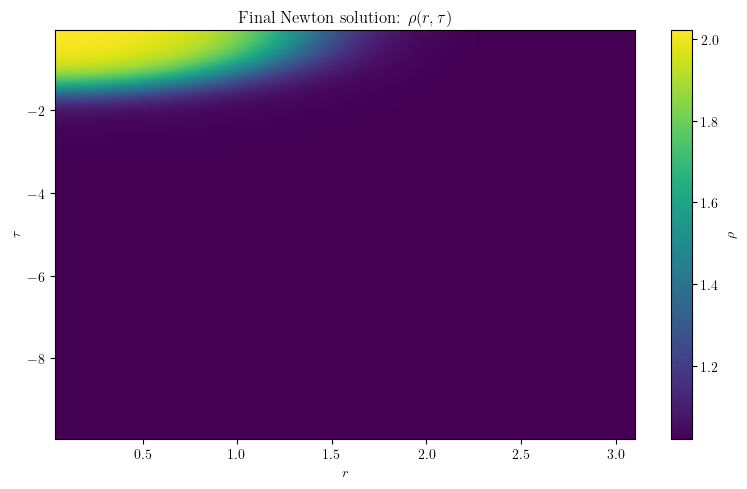

In [30]:
# Unpack final solution and density
y_sol, ybar_sol = solver_newton.unpack(newton_result.x)
phi_sol, phibar_sol = solver_newton.phi(y_sol, ybar_sol)
rho_sol = np.sqrt(np.maximum((phi_sol * phibar_sol).real, 0.0))

# Plot final solution separately
R_f, T_f = np.meshgrid(grid_newton.r, grid_newton.tau, indexing="xy")

fig, ax = plt.subplots(figsize=(8, 5))
cf = ax.pcolormesh(R_f, T_f, rho_sol.T, shading="gouraud", cmap="viridis")
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$\tau$")
ax.set_title(r"Final Newton solution: $\rho(r, \tau)$")
fig.colorbar(cf, ax=ax, label=r"$\rho$")
plt.tight_layout()
plt.show()

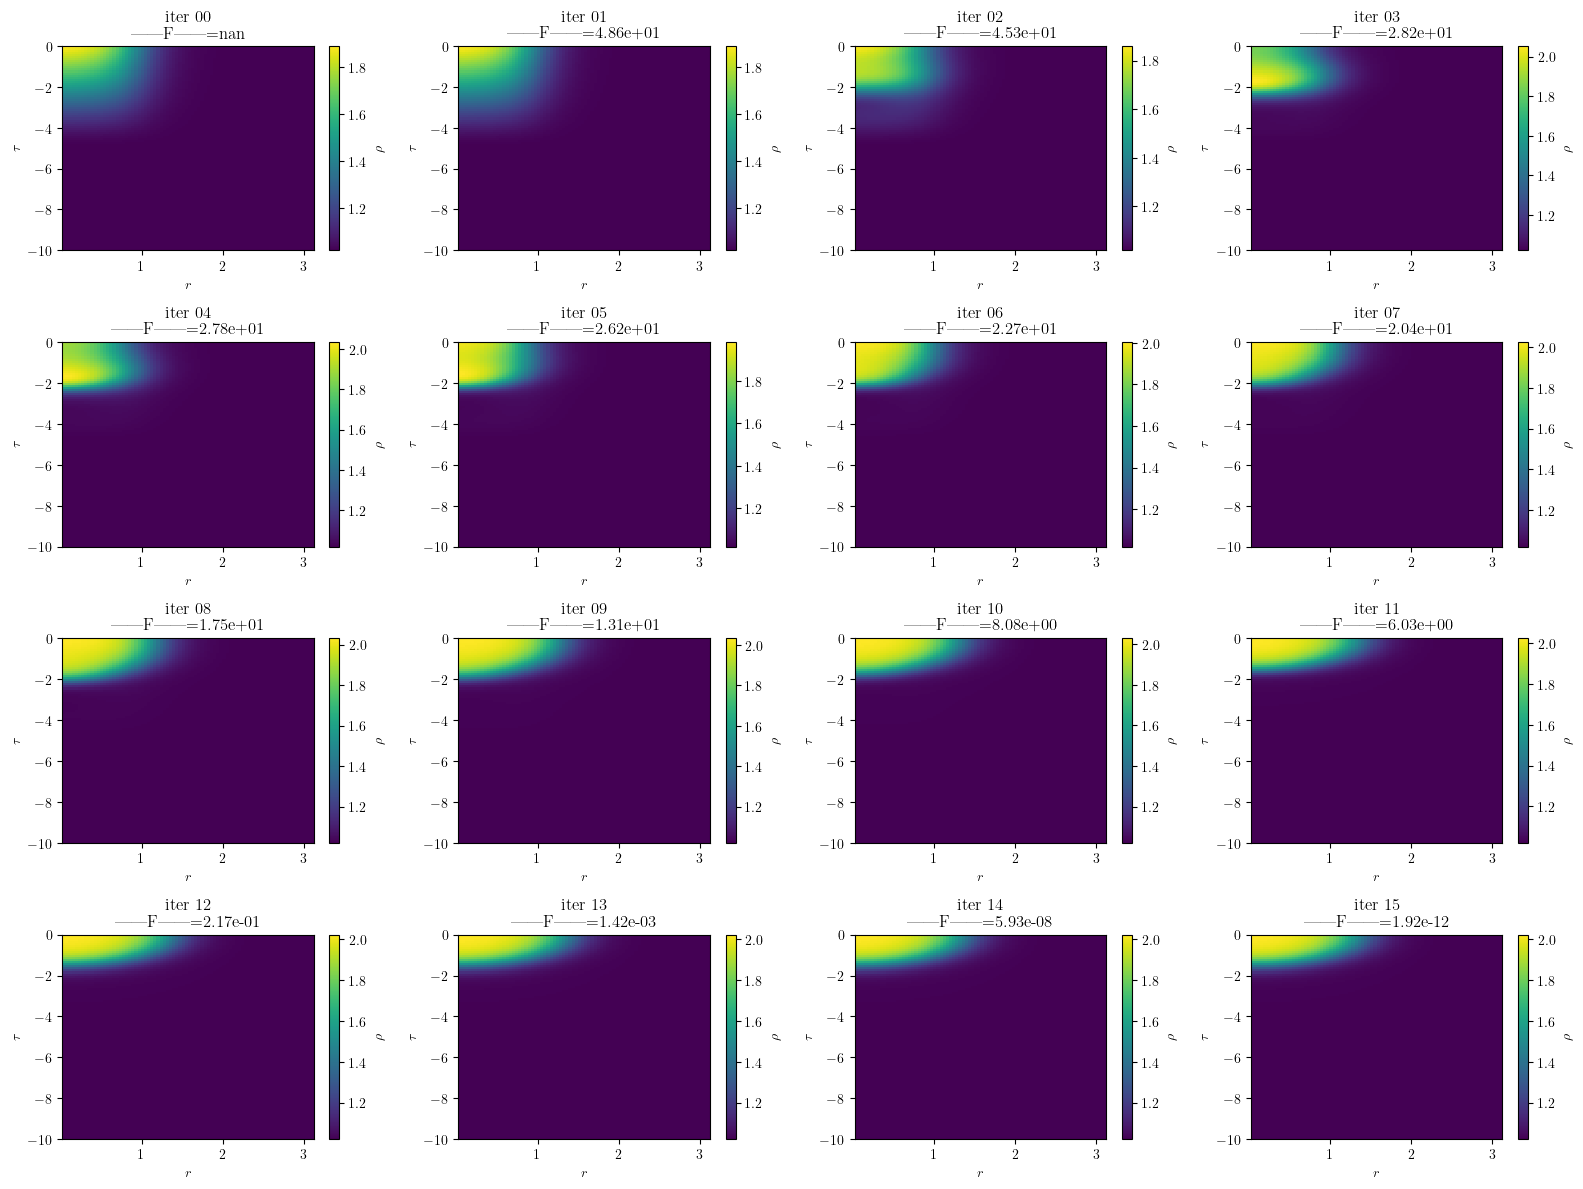

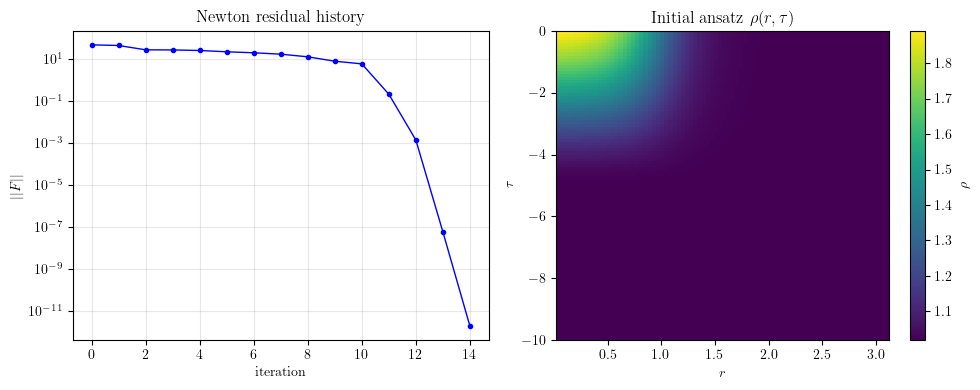

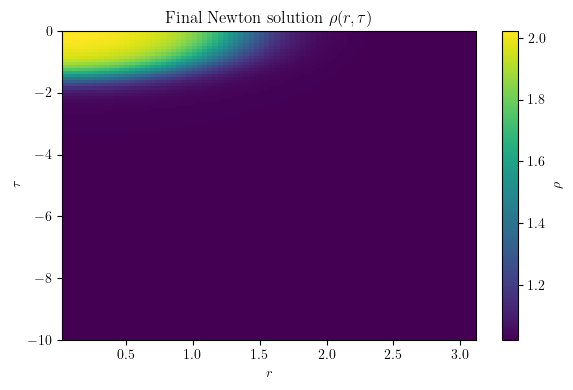

In [31]:
# Newton: residual history + rho at every iteration (when store_iteration_history=True)
R_it, T_it = np.meshgrid(grid_newton.r, grid_newton.tau, indexing="xy")
hist = getattr(newton_result.newton, "history", None) or getattr(newton_result, "history", None)
iteration_history = getattr(newton_result, "iteration_history", None) or []

if iteration_history:
    # Plot rho for each Newton iteration (grid of subplots)
    n_iter = len(iteration_history)
    n_cols = int(np.ceil(np.sqrt(n_iter)))
    n_rows = int(np.ceil(n_iter / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
    axes = np.atleast_1d(axes).ravel()
    for i, it in enumerate(iteration_history):
        ax = axes[i]
        rho_it = it["rho"]
        res = it["res_norm"]
        im = ax.pcolormesh(R_it, T_it, rho_it.T, shading="auto", cmap="viridis")
        ax.set_title(f"iter {it['iter']:02d}\n||F||={res:.2e}")
        ax.set_xlabel(r"$r$")
        ax.set_ylabel(r"$\tau$")
        plt.colorbar(im, ax=ax, label=r"$\rho$")
    for j in range(len(iteration_history), len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()

if hist is not None and len(hist) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    ax = axes[0]
    ax.semilogy(range(len(hist)), hist, "b-o", lw=1, ms=3)
    ax.set_xlabel("iteration")
    ax.set_ylabel(r"$||F||$")
    ax.set_title("Newton residual history")
    ax.grid(True, alpha=0.3)
    y_init, ybar_init = solver_newton.unpack(x0_newton)
    phi_init, phibar_init = solver_newton.phi(y_init, ybar_init)
    rho_init = np.sqrt(np.maximum((phi_init * phibar_init).real, 0.0))
    ax = axes[1]
    im0 = ax.pcolormesh(R_it, T_it, rho_init.T, shading="auto", cmap="viridis")
    ax.set_xlabel(r"$r$")
    ax.set_ylabel(r"$\tau$")
    ax.set_title(r"Initial ansatz $\rho(r,\tau)$")
    plt.colorbar(im0, ax=ax, label=r"$\rho$")
    plt.tight_layout()
    plt.show()

    fig2, ax2 = plt.subplots(1, 1, figsize=(6, 4))
    im2 = ax2.pcolormesh(R_it, T_it, rho_sol.T, shading="auto", cmap="viridis")
    ax2.set_xlabel(r"$r$")
    ax2.set_ylabel(r"$\tau$")
    ax2.set_title(r"Final Newton solution $\rho(r,\tau)$")
    plt.colorbar(im2, ax=ax2, label=r"$\rho$")
    plt.tight_layout()
    plt.show()
else:
    print("No Newton history available; re-run solve with store_iteration_history=True for rho per iteration.")

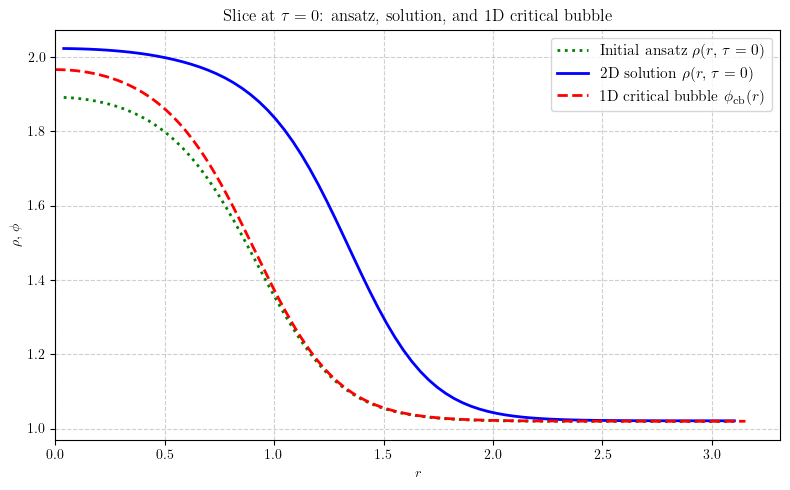

In [32]:
# Slice at τ=0 of the 2D solution vs 1D critical bubble profile and initial ansatz
i_tau0 = np.argmin(np.abs(grid_newton.tau))
rho_at_tau0 = rho_sol[:, i_tau0]

# Initial ansatz (actually given to Newton): unpack x0_newton and get ρ at τ=0
y_init, ybar_init = solver_newton.unpack(x0_newton)
phi_init, phibar_init = solver_newton.phi(y_init, ybar_init)
rho_init = np.sqrt(np.maximum((phi_init * phibar_init).real, 0.0))
rho_init_at_tau0 = rho_init[:, i_tau0]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(grid_newton.r, rho_init_at_tau0, "g:", lw=2, label=r"Initial ansatz $\rho(r,\, \tau=0)$")
ax.plot(grid_newton.r, rho_at_tau0, "b-", lw=2, label=r"2D solution $\rho(r,\, \tau=0)$")
if "r_bounce" in globals() and r_bounce is not None:
    ax.plot(r_bounce, phi_bounce, "r--", lw=2, label=r"1D critical bubble $\phi_{\mathrm{cb}}(r)$")
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$\rho$, $\phi$")
ax.set_title(r"Slice at $\tau=0$: ansatz, solution, and 1D critical bubble")
ax.legend(fontsize=11)
ax.grid(True, ls="--", alpha=0.6)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

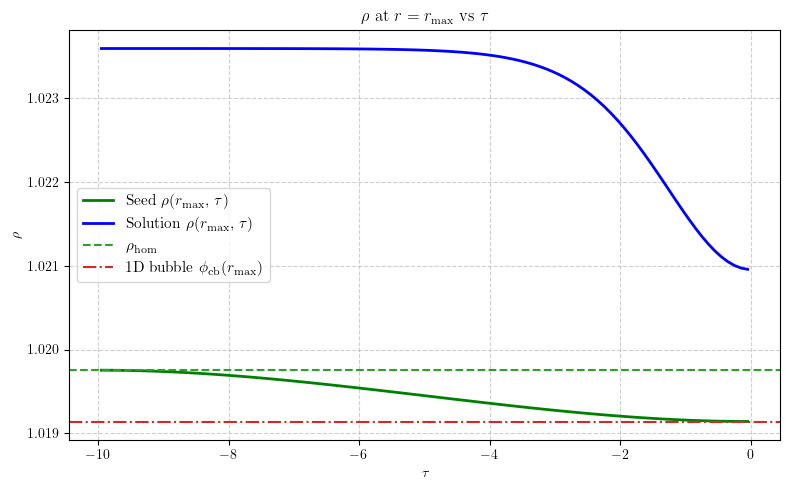

In [33]:
# ρ(r=r_max, τ) vs τ: solution, seed (the one given to Newton), 1D bubble at r_max, and homogeneous
# Rebuild seed ρ from best_x0 with the SAME (ω_ref, ρ_ref) used when building the ansatz (OMEGA, rho_hom),
# so the curve matches the other seed plot. Do NOT use solver_newton.phi (it uses ω̃, ρ̃).
x0_seed = x0_newton  # seed actually passed to Newton
y_seed_ng, ybar_seed_ng = solver_newton.unpack(x0_seed)
# Use solver_newton.phi so seed rho is identical to iteration_history (iter 0)
phi_seed_ng, phibar_seed_ng = solver_newton.phi(y_seed_ng, ybar_seed_ng)
rho_seed_ng = np.sqrt(np.maximum((phi_seed_ng * phibar_seed_ng).real + getattr(solver_newton.settings, 'rho_eps', 1e-12), 0.0))
r_max = grid_newton.r[-1]
rho_at_rmax = rho_sol[-1, :]
rho_seed_at_rmax = rho_seed_ng[-1, :]
rho_hom = float(phi_false_bounce)
#phi_1d_at_rmax = np.interp(r_max, r_bounce, phi_bounce) if "r_bounce" in globals() and r_bounce is not None else None

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(grid_newton.tau, rho_seed_at_rmax, "g", lw=2, label=r"Seed $\rho(r_{\max},\, \tau)$")
ax.plot(grid_newton.tau, rho_at_rmax, "b-", lw=2, label=r"Solution $\rho(r_{\max},\, \tau)$")
ax.axhline(rho_hom, color="C2", ls="--", lw=1.5, label=r"$\rho_{\mathrm{hom}}$")
if phi_bubble_at_rmax is not None:
    ax.axhline(phi_bubble_at_rmax, color="C3", ls="-.", lw=1.5, label=r"1D bubble $\phi_{\mathrm{cb}}(r_{\max})$")
ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$\rho$")
ax.set_title(r"$\rho$ at $r = r_{\max}$ vs $\tau$")
ax.legend(fontsize=11)
ax.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

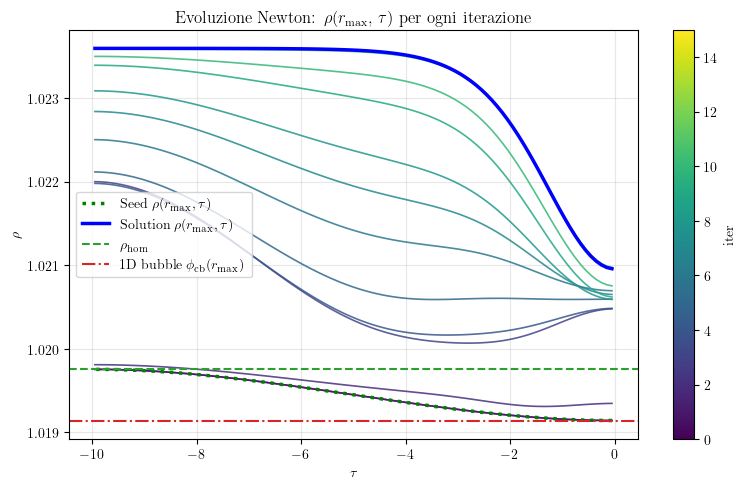

In [34]:
# Evoluzione Newton a r = r_max: ρ(r_max, τ) per ogni iterazione (per vedere dove converge o meno)
iteration_history = getattr(newton_result, "iteration_history", None) or []
if iteration_history:
    tau = grid_newton.tau
    n_iter = len(iteration_history)
    cmap = plt.cm.viridis
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, it in enumerate(iteration_history):
        rho_it = it["rho"]   # shape (Nr, Nt)
        rho_rmax = rho_it[-1, :]
        color = cmap(i / max(n_iter - 1, 1))
        ax.plot(tau, rho_rmax, color=color, lw=1.2, alpha=0.85)
    # Seed a r_max
    x0_seed = x0_newton
    y_seed_ng, ybar_seed_ng = solver_newton.unpack(x0_seed)
    phi_seed_ng, phibar_seed_ng = solver_newton.phi(y_seed_ng, ybar_seed_ng)
    rho_seed_ng = np.sqrt(np.maximum((phi_seed_ng * phibar_seed_ng).real + getattr(solver_newton.settings, 'rho_eps', 1e-12), 0.0))
    rho_seed_at_rmax = rho_seed_ng[-1, :]
    ax.plot(tau, rho_seed_at_rmax, "g", lw=2.5, ls=":", label=r"Seed $\rho(r_{\max},\tau)$")
    ax.plot(tau, rho_sol[-1, :], "b-", lw=2.5, label=r"Solution $\rho(r_{\max},\tau)$")
    ax.axhline(rho_hom, color="C2", ls="--", lw=1.5, label=r"$\rho_{\mathrm{hom}}$")
    if phi_bubble_at_rmax is not None:
        ax.axhline(phi_bubble_at_rmax, color="C3", ls="-.", lw=1.5, label=r"1D bubble $\phi_{\mathrm{cb}}(r_{\max})$")
    ax.set_xlabel(r"$\tau$")
    ax.set_ylabel(r"$\rho$")
    ax.set_title(r"Evoluzione Newton: $\rho(r_{\max},\, \tau)$ per ogni iterazione")
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, n_iter - 1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, label="iter")
    ax.legend(loc="best", fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Nessuna storia iterazioni; rieseguire solve con store_iteration_history=True.")

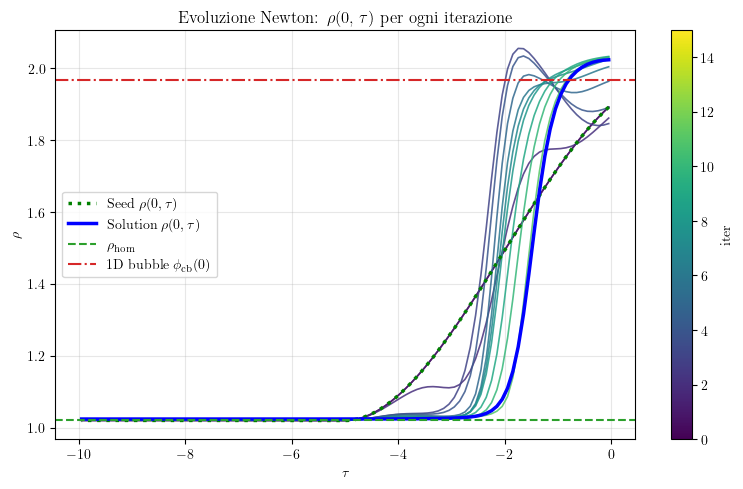

In [35]:
# Stesso plot ma alla slice r = 0: evoluzione ρ(0, τ) vs τ
iteration_history = getattr(newton_result, "iteration_history", None) or []
if iteration_history:
    tau = grid_newton.tau
    n_iter = len(iteration_history)
    cmap = plt.cm.viridis
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, it in enumerate(iteration_history):
        rho_it = it["rho"]   # shape (Nr, Nt)
        rho_r0 = rho_it[0, :]
        color = cmap(i / max(n_iter - 1, 1))
        ax.plot(tau, rho_r0, color=color, lw=1.2, alpha=0.85)
    # Seed a r=0
    x0_seed = x0_newton
    y_seed_ng, ybar_seed_ng = solver_newton.unpack(x0_seed)
    phi_seed_ng, phibar_seed_ng = solver_newton.phi(y_seed_ng, ybar_seed_ng)
    rho_seed_ng = np.sqrt(np.maximum((phi_seed_ng * phibar_seed_ng).real + getattr(solver_newton.settings, 'rho_eps', 1e-12), 0.0))
    rho_seed_at_r0 = rho_seed_ng[0, :]
    ax.plot(tau, rho_seed_at_r0, "g", lw=2.5, ls=":", label=r"Seed $\rho(0,\tau)$")
    ax.plot(tau, rho_sol[0, :], "b-", lw=2.5, label=r"Solution $\rho(0,\tau)$")
    ax.axhline(rho_hom, color="C2", ls="--", lw=1.5, label=r"$\rho_{\mathrm{hom}}$")
    if phi0_bounce is not None:
        ax.axhline(phi0_bounce, color="C3", ls="-.", lw=1.5, label=r"1D bubble $\phi_{\mathrm{cb}}(0)$")
    ax.set_xlabel(r"$\tau$")
    ax.set_ylabel(r"$\rho$")
    ax.set_title(r"Evoluzione Newton: $\rho(0,\, \tau)$ per ogni iterazione")
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, n_iter - 1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, label="iter")
    ax.legend(loc="best", fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Nessuna storia iterazioni; rieseguire solve con store_iteration_history=True.")

## Scan eta0 to match charge with homogeneous

Continuation in eta0 starting from the converged Newton solution (section 6). We bisect on eta0 until the 2D charge Q matches the initial homogeneous charge Q_hom.

In [38]:
# ============================================================================
# Scan eta0 to match Q with Q_hom (charge increases with eta0)
# ============================================================================
# Uses: solver_newton, newton_result, ETA0 from section 6; Q_hom from homogeneous charge.
# Step 1: if Q < Q_target, increase eta0 by d_eta and solve; repeat until Q >= Q_target.
# Step 2: when Q crosses target, bracket and bisect to find eta*.

from Bubble_finder.bounce2d import NewtonConvergenceError
from scipy.optimize import brentq

Q_target_eta = Q_hom if "Q_hom" in dir() else float(solver_newton.rho0) * 1.0
d_eta = 0.2
max_scan_steps = 40
tol_Q = 1e-6 * max(1.0, abs(Q_target_eta))

def solve_at_eta(solver, eta, x0):
    solver.settings.eta0 = float(eta)
    solver.eta0 = float(eta)
    sol = solver.solve(x0, verbose=False)
    return float(sol.Q_tau0.real), sol

x_seed = np.array(newton_result.x, copy=True)
eta_curr = float(ETA0)
Q_curr, sol_curr = solve_at_eta(solver_newton, eta_curr, x_seed)
x_seed = sol_curr.x

print(f"Target Q = {Q_target_eta:.6f}, d_eta = {d_eta}")
print(f"Initial: eta0 = {eta_curr:.6f}, Q = {Q_curr:.6f}")

# Step 1: step in eta until we cross Q_target
eta_prev, Q_prev = eta_curr, Q_curr
bracket_found = False
for step in range(max_scan_steps):
    if abs(Q_curr - Q_target_eta) < tol_Q:
        eta_star = eta_curr
        sol_eta = sol_curr
        Q_final = Q_curr
        print(f"Already at target after {step} steps.")
        bracket_found = False
        break
    if Q_curr < Q_target_eta:
        eta_prev, Q_prev = eta_curr, Q_curr
        eta_curr += d_eta
        Q_curr, sol_curr = solve_at_eta(solver_newton, eta_curr, x_seed)
        x_seed = sol_curr.x
        print(f"  step {step+1}: eta={eta_curr:.4f}, Q={Q_curr:.6f}")
        if Q_curr >= Q_target_eta:
            eta_lo, eta_hi = eta_prev, eta_curr
            bracket_found = True
            break
    else:
        eta_prev, Q_prev = eta_curr, Q_curr
        eta_curr -= d_eta
        Q_curr, sol_curr = solve_at_eta(solver_newton, eta_curr, x_seed)
        x_seed = sol_curr.x
        print(f"  step {step+1}: eta={eta_curr:.4f}, Q={Q_curr:.6f}")
        if Q_curr <= Q_target_eta:
            eta_lo, eta_hi = eta_curr, eta_prev
            bracket_found = True
            break
else:
    raise RuntimeError("Scan did not cross Q_target within max_scan_steps.")

# Step 2: bisection (only if we crossed the target)
if bracket_found:
    state = {"x_seed": x_seed.copy(), "sol_curr": sol_curr}
    def f_eta(eta):
        q, s = solve_at_eta(solver_newton, eta, state["x_seed"])
        state["x_seed"] = s.x
        state["sol_curr"] = s
        return q - Q_target_eta

    eta_star = float(brentq(f_eta, eta_lo, eta_hi, xtol=1e-10))
    sol_eta = state["sol_curr"]
    Q_final = float(sol_eta.Q_tau0.real)

print(f"\nEta scan completed: eta* = {eta_star:.6f}")
print(f"  Q(eta*) = {Q_final:.6f}  (target {Q_target_eta:.6f}, ratio {Q_final/Q_target_eta:.6f})")
print(f"  Newton: success={sol_eta.success}, ||F||={sol_eta.residual_norm:.4e}")


Newton converged — diagnostica risultati
  Convergenza: success, iterazioni = 1
  Residuo finale ||F|| = 1.917490e-12
  Carica Q(τ[0])      = +8.014617e+01  (primo slice, tau=-Δτ/2)
  Energia E(τ=0) slice = 5.974975e+01  (su griglia τ[0])
  Energia E(τ=0) ghost = 5.972127e+01  (ricostruita a τ=0 come Q-ball)
  Sanity (η0=0): ||F||=1.940e+01, ω²−W(ρ0)=4.159e-02

Target Q = 81.987978, d_eta = 0.2
Initial: eta0 = 0.000000, Q = 80.146168

Newton converged — diagnostica risultati
  Convergenza: success, iterazioni = 5
  Residuo finale ||F|| = 8.805534e-09
  Carica Q(τ[0])      = +8.152343e+01  (primo slice, tau=-Δτ/2)
  Energia E(τ=0) slice = 6.108847e+01  (su griglia τ[0])
  Energia E(τ=0) ghost = 6.105905e+01  (ricostruita a τ=0 come Q-ball)
  Sanity (η0=0): ||F||=1.940e+01, ω²−W(ρ0)=4.159e-02

  step 1: eta=0.2000, Q=81.523425

Newton converged — diagnostica risultati
  Convergenza: success, iterazioni = 5
  Residuo finale ||F|| = 8.818032e-09
  Carica Q(τ[0])      = +8.290441e+01  (pri

In [ ]:
# Plot solution from eta0 scan (Q-matched at eta*)
rho_eta = solver_newton.rho_map(sol_eta.y, sol_eta.ybar)
r_plt = np.asarray(solver_newton.grid.r, float)
tau_plt = np.asarray(solver_newton.grid.tau, float)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im = axes[0].pcolormesh(r_plt, tau_plt, rho_eta.T, shading="auto", cmap="viridis")
axes[0].set_xlabel(r"$r$")
axes[0].set_ylabel(r"$\tau$")
axes[0].set_title(r"$\rho(r,\tau)$ at $\eta^*={:.4f}$ (Q-matched)".format(eta_star))
plt.colorbar(im, ax=axes[0], label=r"$\rho$")

axes[1].plot(r_plt, rho_eta[:, 0], "b-", lw=1.5, label=r"$\rho(r,\tau=0)$")
axes[1].plot(r_plt, rho_eta[:, -1], "g-", lw=1.5, label=r"$\rho(r,\tau=-\beta/2)$")
r_cb = r_1d if "r_1d" in dir() else globals().get("r_bounce")
phi_cb = phi_1d if "phi_1d" in dir() else globals().get("phi_bounce")
if r_cb is not None and phi_cb is not None:
    axes[1].plot(r_cb, phi_cb, "r--", alpha=0.7, label="1D bounce")
axes[1].axhline(float(solver_newton.rho0), color="gray", ls=":", label=r"$\rho_0$")
axes[1].set_xlabel(r"$r$")
axes[1].set_ylabel(r"$\rho$")
axes[1].set_title("Slices at turning points")
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, None)
plt.tight_layout()
plt.show()